# Input Binding Data Exploration

## Purpose: 

{TODO}

## Packages and Options

In [1]:
import pandas as pd
pd.set_option('display.max_rows', 1000000)
pd.set_option('display.max_columns', 1000000)
pd.set_option('display.max_colwidth', 10000000)

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import seaborn as sns 
import matplotlib.pyplot as plt
import itertools, glob, scipy.stats, numpy, tanglegram

## Literals

In [2]:
# dictionary to rename the splice junction positions to numbers
splice_junction_position_renaming = {
    "5_left": 1, 
    "5_right": 2, 
    "center_left": 3, 
    "center_right": 4, 
    "3_left": 5, 
    "3_right": 6
}

# path and regular expression to get the necessary data 
binding_data_path_regex = "../output/control_only_cleaned_input_binding_data/*-100-*csv.gz"

# different types of hierarchical clustering linkage methods 
linkage_methods = ["single", "complete", "average"]

# maximum value to show on heatmap (due to heavy skewedness of data) 
max_heatmap_value = 25000

## Load Data and Subset to Binding Information Only

In [3]:
# store all input binding data per cell line
all_binding_data = {
    "HepG2": dict(),
    "K562": dict()
}

# for each file in the data path and regex pattern 
for file in sorted(glob.glob(binding_data_path_regex)): 
    
    file = file.replace("\\", "/")
    file
    
    # parse out cell line and binding window size used 
    cell_line = file.split("/")[-1].split("-")[0]
    window_size = file.split("/")[-1].split("-")[1]
    
    # read in pandas 
    binding_data = pd.read_csv(
        file, 
        sep=",", 
        compression="gzip", 
    )
    
    # make sure no NaN values in the DataFrame
    assert binding_data.isna().values.any() == False
    
    # subset only to columns that are related to eCLIP binding
    binding_data = binding_data.loc[
         :, binding_data.columns.str.endswith(
                 ("_right", "_left")
             )
     ]
    
    # convert all 0/1 columns to int8 as they don't need 64 bits
    for column in binding_data.columns:
        if binding_data[column].dtype == 'int64':
            binding_data[column] = binding_data[column].astype("int8")

    # make sure every value in the DataFrame is either a 1 (binding) or 0 (not binding)
    assert all([binding_data[column].isin([0,1]).all() for column in binding_data.columns])
    
    # save the data 
    all_binding_data[cell_line][window_size] = binding_data


'../output/control_only_cleaned_input_binding_data/HepG2-100-50-50.csv.gz'

'../output/control_only_cleaned_input_binding_data/K562-100-50-50.csv.gz'

In [4]:
binding_data.head()

,AARS_5_left,AATF_5_left,ABCF1_5_left,ADAT1_5_left,AGGF1_5_left,AKAP1_5_left,AKAP8L_5_left,APEX1_5_left,APOBEC3C_5_left,AQR_5_left,BUD13_5_left,CPEB4_5_left,CPSF6_5_left,CSTF2T_5_left,DDX1_5_left,DDX21_5_left,DDX24_5_left,DDX3X_5_left,DDX42_5_left,DDX43_5_left,DDX47_5_left,DDX51_5_left,DDX52_5_left,DDX55_5_left,DDX6_5_left,DGCR8_5_left,DHX30_5_left,DROSHA_5_left,EEF2_5_left,EFTUD2_5_left,EIF3G_5_left,EIF4E_5_left,EIF4G2_5_left,ELAC2_5_left,ELAVL1_5_left,EWSR1_5_left,EXOSC10_5_left,EXOSC5_5_left,FAM120A_5_left,FASTKD2_5_left,FMR1_5_left,FTO_5_left,FUS_5_left,FXR1_5_left,FXR2_5_left,GARS_5_left,GEMIN5_5_left,GNL3_5_left,GPKOW_5_left,GRWD1_5_left,GTF2F1_5_left,HLTF_5_left,HNRNPA1_5_left,HNRNPC_5_left,HNRNPK_5_left,HNRNPL_5_left,HNRNPM_5_left,HNRNPU_5_left,HNRNPUL1_5_left,IGF2BP1_5_left,IGF2BP2_5_left,ILF3_5_left,KHDRBS1_5_left,KHSRP_5_left,LARP4_5_left,LARP7_5_left,LIN28B_5_left,LSM11_5_left,MATR3_5_left,MBNL1_5_left,METAP2_5_left,METTL1_5_left,MORC2_5_left,MTPAP_5_left,NCBP2_5_left,NIPBL_5_left,NOLC1_5_left,NONO_5_left,NPM1_5_left,NSUN2_5_left,PABPC4_5_left,PCBP1_5_left,PHF6_5_left,PPIL4_5_left,PRPF8_5_left,PTBP1_5_left,PUM1_5_left,PUM2_5_left,PUS1_5_left,QKI_5_left,RBFOX2_5_left,RBM15_5_left,RBM22_5_left,RNF187_5_left,RPS10_5_left,RPS11_5_left,RPS3_5_left,RPS6_5_left,RYBP_5_left,SAFB_5_left,SAFB2_5_left,SBDS_5_left,SDAD1_5_left,SERBP1_5_left,SF3B1_5_left,SF3B4_5_left,SLBP_5_left,SLTM_5_left,SMNDC1_5_left,SND1_5_left,SRSF1_5_left,SRSF7_5_left,SRSF9_5_left,SSB_5_left,SUPV3L1_5_left,TAF15_5_left,TARDBP_5_left,TBRG4_5_left,TIA1_5_left,TRA2A_5_left,TROVE2_5_left,U2AF1_5_left,U2AF2_5_left,UCHL5_5_left,UPF1_5_left,UTP18_5_left,UTP3_5_left,WDR3_5_left,WDR43_5_left,WRN_5_left,XRCC6_5_left,XRN2_5_left,YBX3_5_left,YWHAG_5_left,ZC3H11A_5_left,ZC3H8_5_left,ZNF622_5_left,ZNF800_5_left,ZRANB2_5_left,AARS_5_right,AATF_5_right,ABCF1_5_right,ADAT1_5_right,AGGF1_5_right,AKAP1_5_right,AKAP8L_5_right,APEX1_5_right,APOBEC3C_5_right,AQR_5_right,BUD13_5_right,CPEB4_5_right,CPSF6_5_right,CSTF2T_5_right,DDX1_5_right,DDX21_5_right,DDX24_5_right,DDX3X_5_right,DDX42_5_right,DDX43_5_right,DDX47_5_right,DDX51_5_right,DDX52_5_right,DDX55_5_right,DDX6_5_right,DGCR8_5_right,DHX30_5_right,DROSHA_5_right,EEF2_5_right,EFTUD2_5_right,EIF3G_5_right,EIF4E_5_right,EIF4G2_5_right,ELAC2_5_right,ELAVL1_5_right,EWSR1_5_right,EXOSC10_5_right,EXOSC5_5_right,FAM120A_5_right,FASTKD2_5_right,FMR1_5_right,FTO_5_right,FUS_5_right,FXR1_5_right,FXR2_5_right,GARS_5_right,GEMIN5_5_right,GNL3_5_right,GPKOW_5_right,GRWD1_5_right,GTF2F1_5_right,HLTF_5_right,HNRNPA1_5_right,HNRNPC_5_right,HNRNPK_5_right,HNRNPL_5_right,HNRNPM_5_right,HNRNPU_5_right,HNRNPUL1_5_right,IGF2BP1_5_right,IGF2BP2_5_right,ILF3_5_right,KHDRBS1_5_right,KHSRP_5_right,LARP4_5_right,LARP7_5_right,LIN28B_5_right,LSM11_5_right,MATR3_5_right,MBNL1_5_right,METAP2_5_right,METTL1_5_right,MORC2_5_right,MTPAP_5_right,NCBP2_5_right,NIPBL_5_right,NOLC1_5_right,NONO_5_right,NPM1_5_right,NSUN2_5_right,PABPC4_5_right,PCBP1_5_right,PHF6_5_right,PPIL4_5_right,PRPF8_5_right,PTBP1_5_right,PUM1_5_right,PUM2_5_right,PUS1_5_right,QKI_5_right,RBFOX2_5_right,RBM15_5_right,RBM22_5_right,RNF187_5_right,RPS10_5_right,RPS11_5_right,RPS3_5_right,RPS6_5_right,RYBP_5_right,SAFB_5_right,SAFB2_5_right,SBDS_5_right,SDAD1_5_right,SERBP1_5_right,SF3B1_5_right,SF3B4_5_right,SLBP_5_right,SLTM_5_right,SMNDC1_5_right,SND1_5_right,SRSF1_5_right,SRSF7_5_right,SRSF9_5_right,SSB_5_right,SUPV3L1_5_right,TAF15_5_right,TARDBP_5_right,TBRG4_5_right,TIA1_5_right,TRA2A_5_right,TROVE2_5_right,U2AF1_5_right,U2AF2_5_right,UCHL5_5_right,UPF1_5_right,UTP18_5_right,UTP3_5_right,WDR3_5_right,WDR43_5_right,WRN_5_right,XRCC6_5_right,XRN2_5_right,YBX3_5_right,YWHAG_5_right,ZC3H11A_5_right,ZC3H8_5_right,ZNF622_5_right,ZNF800_5_right,ZRANB2_5_right,AARS_center_left,AATF_center_left,ABCF1_center_left,ADAT1_center_left,AGGF1_center_left,AKAP1_center_left,AKAP8L_center_left,APEX1_center_left,APOBEC3C_center_left,AQR_center_left,BUD13_center_left,CPEB4_center_left,CPSF6_center_lef

In [5]:
"RBP-Position Combinations that are all 0"

# for each cell line and window size 
for cell_line in all_binding_data: 
    for window_size in all_binding_data[cell_line]:
        "{} {}".format(cell_line, window_size)
        
        tmp_df = all_binding_data[cell_line][window_size]
        
        # list to indicate all those RBP-position combinations that are empty 
        empty=[]
        
        # check if there are RBP positions that only have 0's
        for column in tmp_df.columns:
            if (tmp_df[column]==0).all(): 
                empty.append(column)
                
        print(empty)

'RBP-Position Combinations that are all 0'

'HepG2 100'

['DHX30_5_left', 'HNRNPA1_5_left', 'SAFB_5_left', 'TBRG4_5_left', 'DHX30_5_right', 'HNRNPU_5_right', 'POLR2G_5_right', 'TBRG4_5_right', 'DHX30_center_left', 'POLR2G_center_left', 'TBRG4_center_left', 'DHX30_center_right', 'POLR2G_center_right', 'TBRG4_center_right', 'POLR2G_3_left', 'TBRG4_3_left', 'HNRNPA1_3_right', 'POLR2G_3_right', 'TBRG4_3_right', 'XRCC6_3_right']


'K562 100'

['AARS_5_left', 'GNL3_5_left', 'PUS1_5_left', 'SBDS_5_left', 'SUPV3L1_5_left', 'AARS_5_right', 'ABCF1_5_right', 'HNRNPU_5_right', 'PUS1_5_right', 'RPS11_5_right', 'RYBP_5_right', 'SBDS_5_right', 'SF3B1_5_right', 'UTP3_5_right', 'WDR3_5_right', 'GNL3_center_left', 'PUS1_center_left', 'SBDS_center_left', 'AARS_center_right', 'GNL3_center_right', 'PUS1_center_right', 'RPS11_center_right', 'SBDS_center_right', 'SLBP_center_right', 'WDR3_center_right', 'AARS_3_left', 'PUS1_3_left', 'SBDS_3_left', 'UTP3_3_left', 'AARS_3_right', 'GNL3_3_right', 'HNRNPU_3_right', 'PUS1_3_right', 'SBDS_3_right', 'SUPV3L1_3_right', 'UTP3_3_right', 'WDR3_3_right']


## Which RBPs Bind the Most When Considering All 6 Positions?

<Figure size 2000x600 with 0 Axes>

Text(0.5, 1.0, 'Total # RBP Binding Sites Across All 6 Positions (HepG2: 100 Window)')

<Axes: title={'center': 'Total # RBP Binding Sites Across All 6 Positions (HepG2: 100 Window)'}>

Text(113.69444444444443, 0.5, 'Total # RBP Binding Sites')

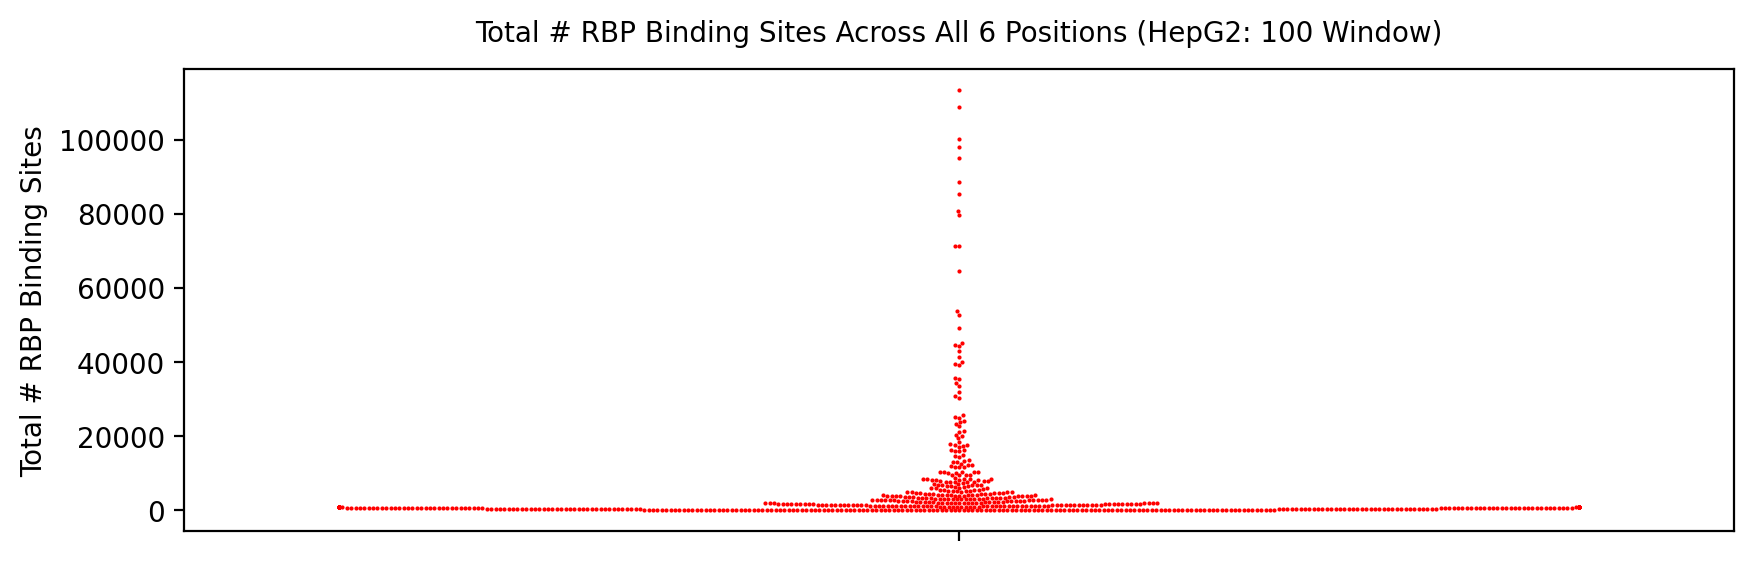

<Figure size 8000x400 with 0 Axes>

Text(0.5, 1.0, 'Total # RBP Binding Sites Across All 6 Positions (HepG2: 100 Window)')

<Axes: title={'center': 'Total # RBP Binding Sites Across All 6 Positions (HepG2: 100 Window)'}>

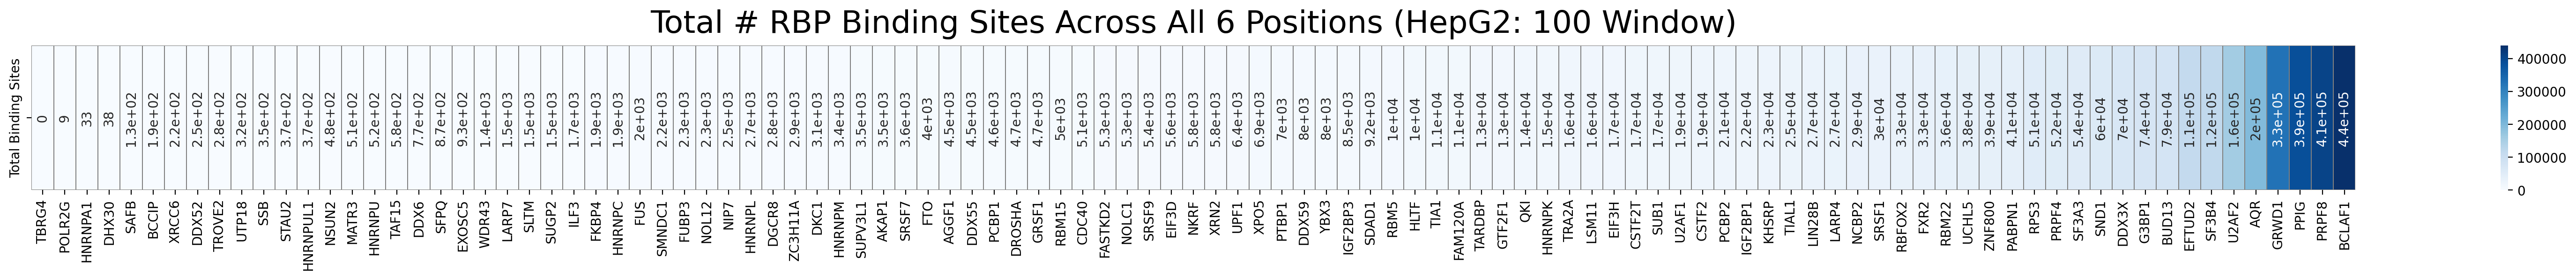

<Figure size 2000x600 with 0 Axes>

Text(0.5, 1.0, 'Total # RBP Binding Sites Across All 6 Positions (K562: 100 Window)')

<Axes: title={'center': 'Total # RBP Binding Sites Across All 6 Positions (K562: 100 Window)'}>

Text(113.69444444444443, 0.5, 'Total # RBP Binding Sites')

/home/jve4pt/.local/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 18.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


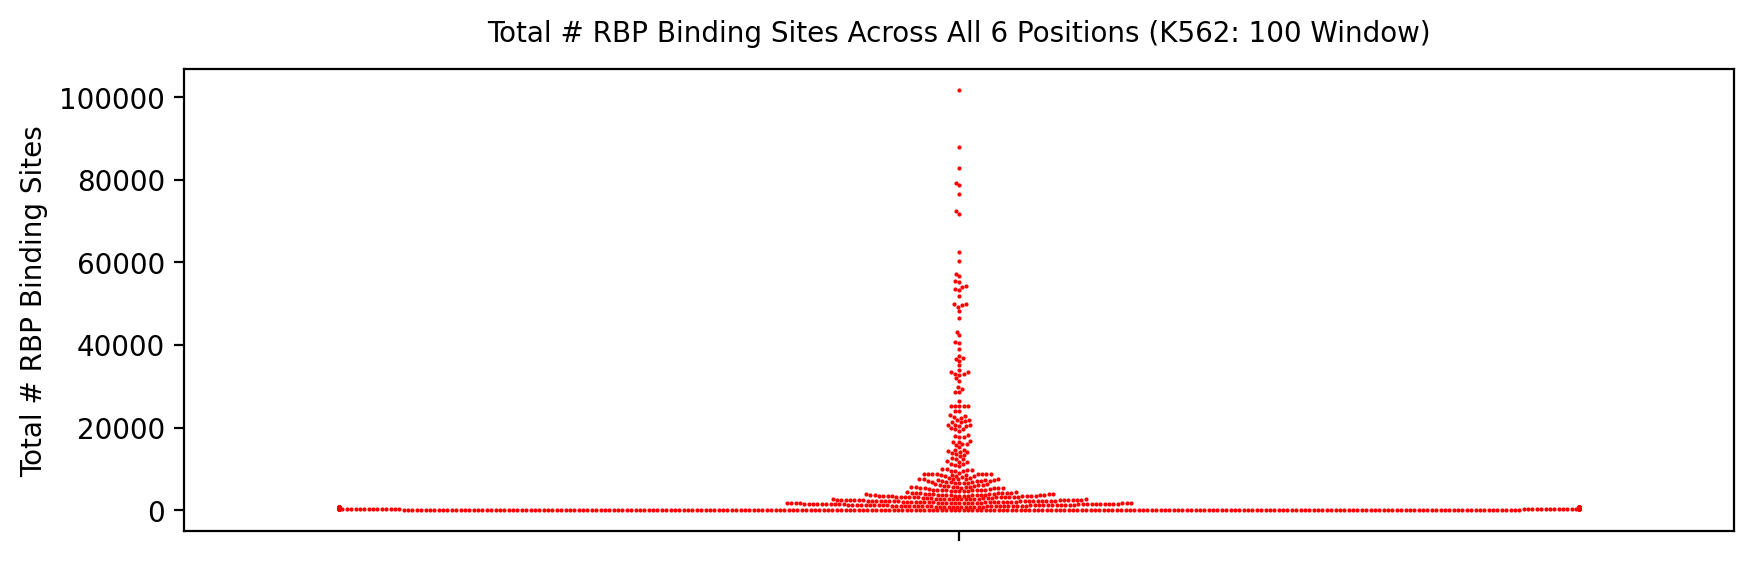

<Figure size 8000x400 with 0 Axes>

Text(0.5, 1.0, 'Total # RBP Binding Sites Across All 6 Positions (K562: 100 Window)')

<Axes: title={'center': 'Total # RBP Binding Sites Across All 6 Positions (K562: 100 Window)'}>

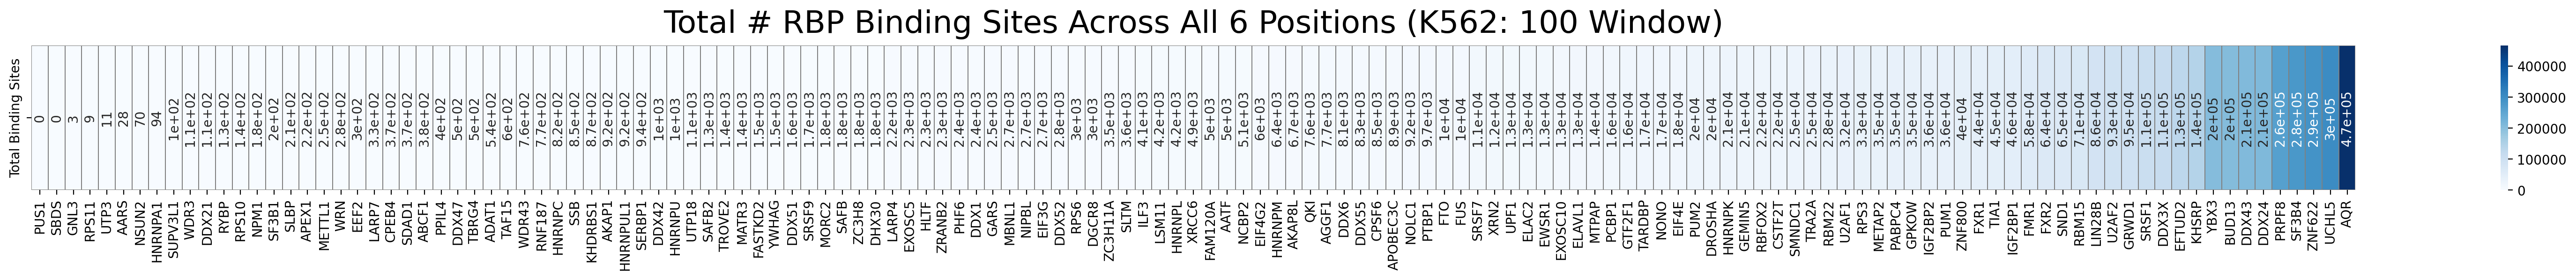

In [6]:
# for each cell line and window size 
for cell_line in all_binding_data:     
    for window_size in all_binding_data[cell_line]: 
        
        # get number of binding sites per each RBP-position combination 
        tmp_num_binding_sites = all_binding_data[cell_line][window_size].sum(axis=0)        
        
        # parse out each unique RBP in the dataset 
        all_rbps = list(set([rbp_position.split("_")[0] for rbp_position in tmp_num_binding_sites.index]))
        
        # create lists to be index and values for new DataFrame 
        # index = "RBP" and value = "number of times RBP bound to any position"
        df_index = []
        total_binding = []
        
        # for each unique rbp 
        for rbp in all_rbps: 
                        
            # sum up number of binding sites across all positions for each rbp and save
            total_binding.append(
                tmp_num_binding_sites[tmp_num_binding_sites.index.str.contains(rbp)].sum()
            )
            # add RBP to index 
            df_index.append(rbp)
        
        # create dataframe with one column and sort RBPs by total number of binding sites 
        tmp_df = pd.DataFrame(total_binding, index=df_index, columns=["Total Binding Sites"]).sort_values("Total Binding Sites").T
        
        # create horizontal swarmplot
        plt.figure(figsize=(10,3), dpi=200)
        plt.title("Total # RBP Binding Sites Across All 6 Positions ({}: {} Window)".format(cell_line, window_size), fontsize=10, pad=10)
        sns.swarmplot(tmp_num_binding_sites, orient="v", size=1.5, color="red")
        plt.ylabel("Total # RBP Binding Sites")
        plt.show()

        # create horizontal heatmap and include rotated annotations for number of total binding sites 
        plt.figure(figsize=(40,2), dpi=200)
        plt.title("Total # RBP Binding Sites Across All 6 Positions ({}: {} Window)".format(cell_line, window_size), fontsize=24, pad=10)
        sns.heatmap(tmp_df, linewidth=0.1, linecolor="grey", annot=True, annot_kws={'rotation':90}, cmap="Blues")
        plt.show()

## What is the Distribution of Number of Bindings per Each RBP-Position Combination?

In [7]:
# dict to store number of binding sites for each RBP position combination 
# {cell line: {window size: value}}
num_binding_sites = {}

# for each cell line and window size
for cell_line in all_binding_data: 
    num_binding_sites[cell_line] = {}
    
    for window_size in all_binding_data[cell_line]: 
        
        # sum up the number of binding sites per RBP-Position combination and save to dict 
        tmp_num_binding_sites = all_binding_data[cell_line][window_size].sum(axis=0)        
        num_binding_sites[cell_line][window_size] = tmp_num_binding_sites


#### Swarmplot of all RBP-Position Combinations

<Figure size 2000x600 with 0 Axes>

<Axes: >

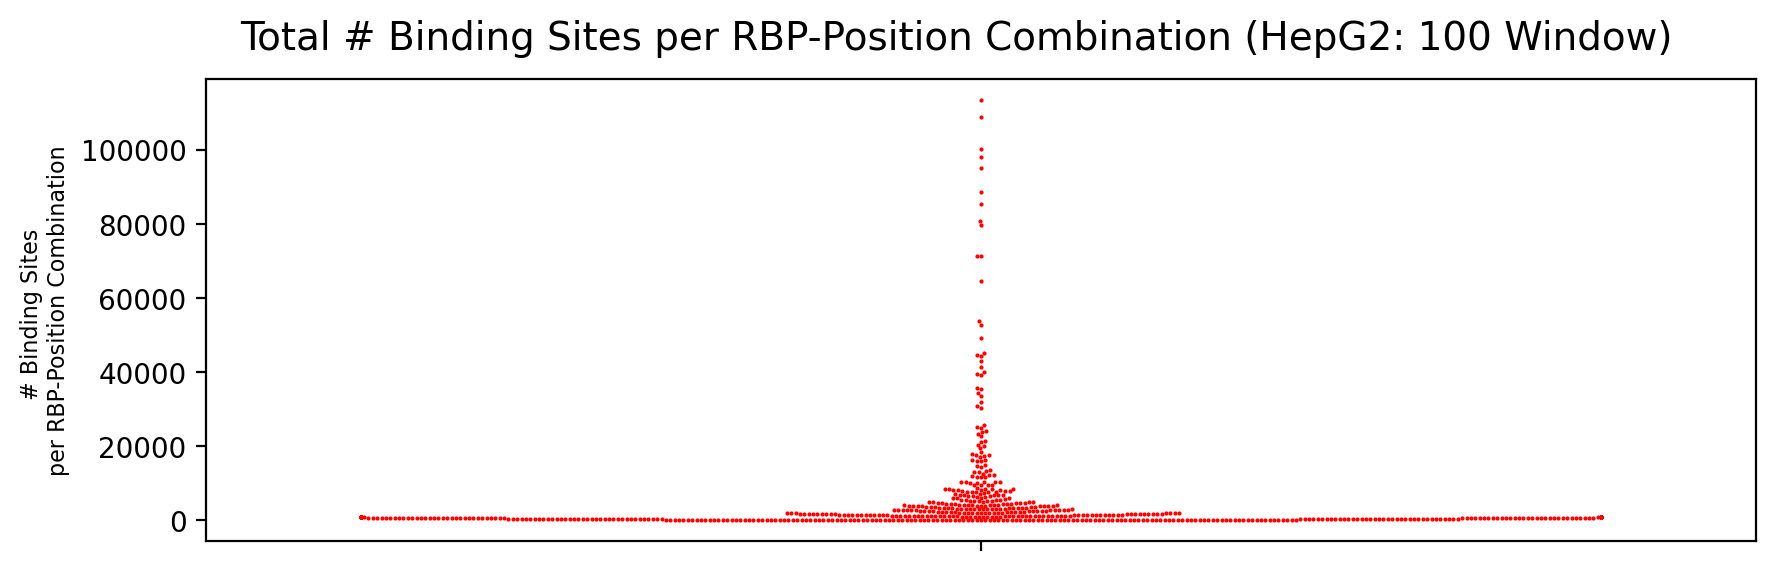

<Figure size 2000x600 with 0 Axes>

<Axes: >

/home/jve4pt/.local/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 18.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


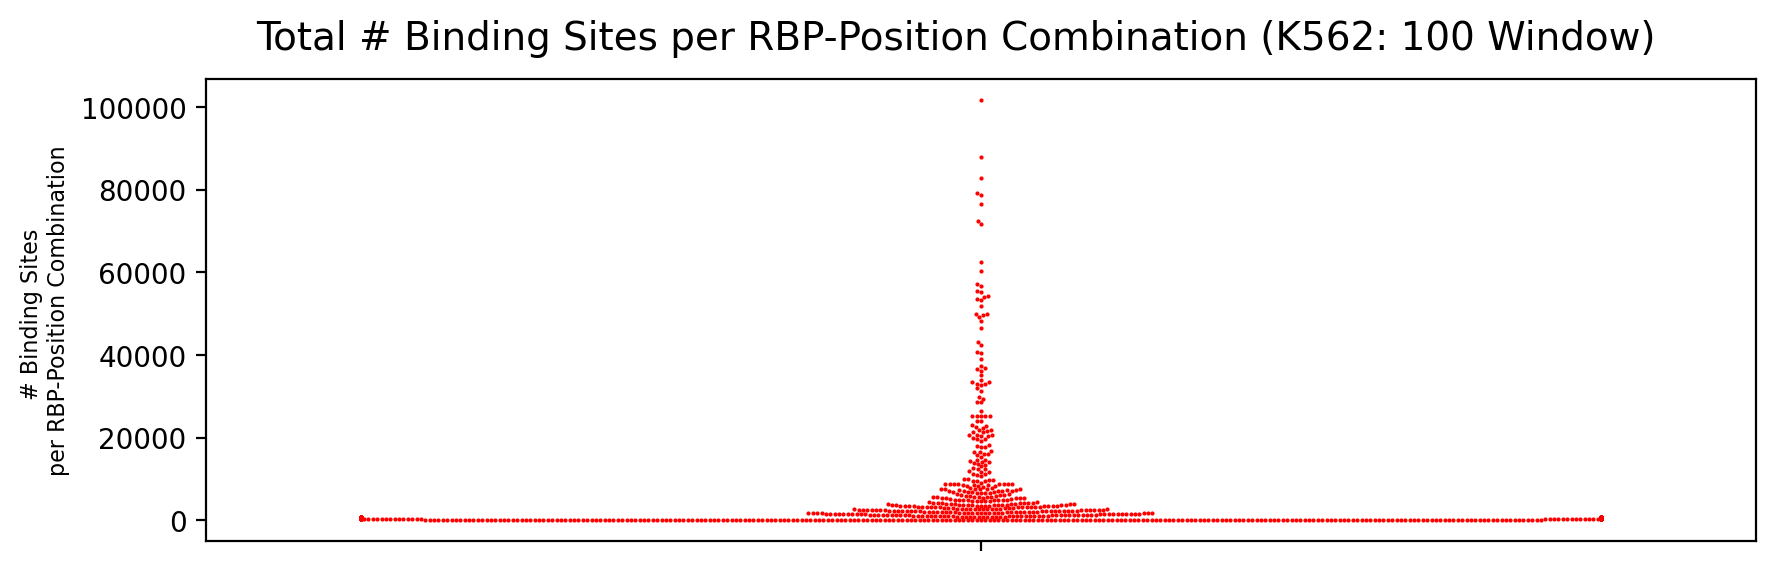

In [8]:
# for each cell line and window size 
for cell_line in num_binding_sites: 
    for window_size in num_binding_sites[cell_line]: 
        
        tmp_num_binding_sites = num_binding_sites[cell_line][window_size]
        
        # create a swarmplot that is horizontal and small point size because there are a lot of points near 0 
        plt.figure(figsize=(10,3), dpi=200)
        
        sns.swarmplot(tmp_num_binding_sites, orient="v", size=1.5, color="red")
        
        _=plt.suptitle("Total # Binding Sites per RBP-Position Combination ({}: {} Window)".format(cell_line, window_size), fontsize=14)
        _=plt.ylabel("# Binding Sites \nper RBP-Position Combination", fontsize=8)
        
        plt.show()

#### Histogram of all RBP-Position combinations

<Axes: ylabel='Count'>

<Axes: ylabel='Count'>

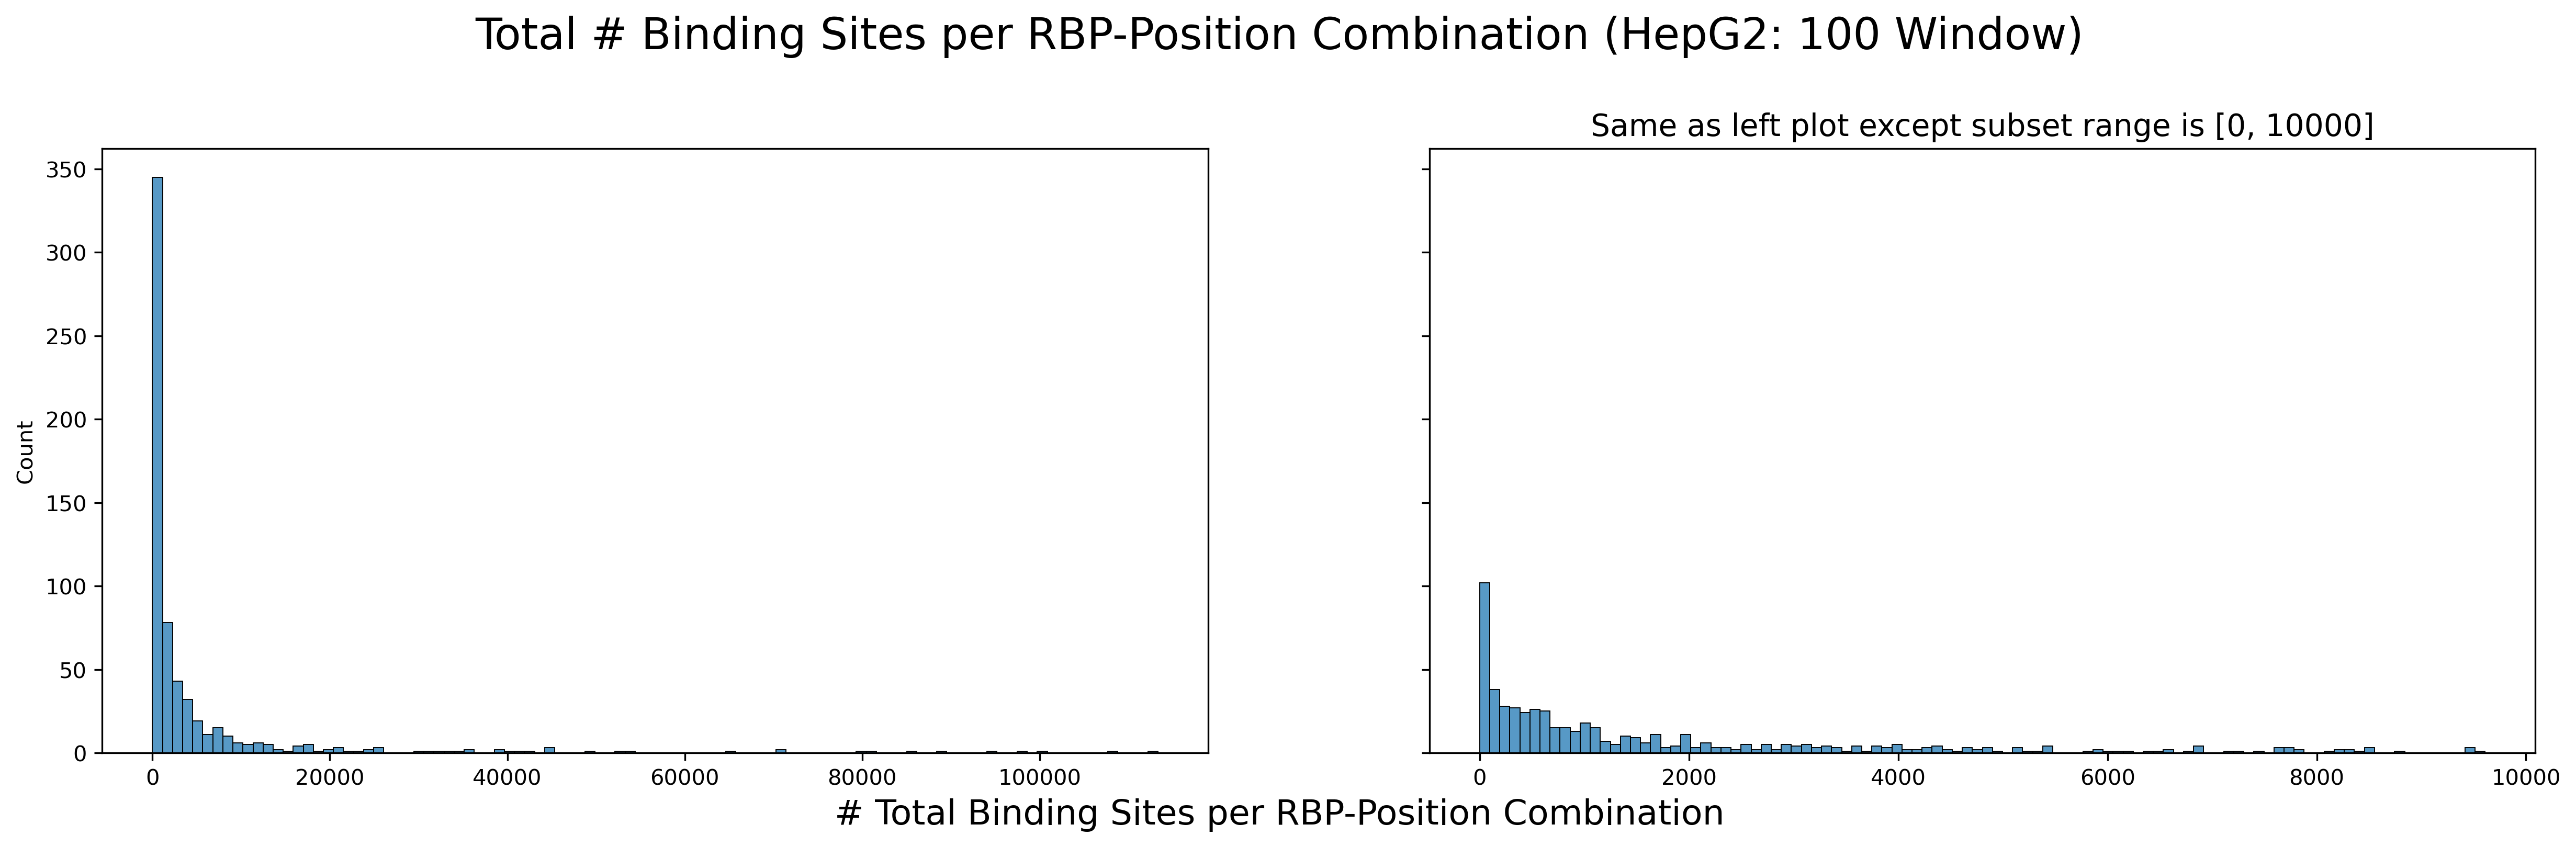

<Axes: ylabel='Count'>

<Axes: ylabel='Count'>

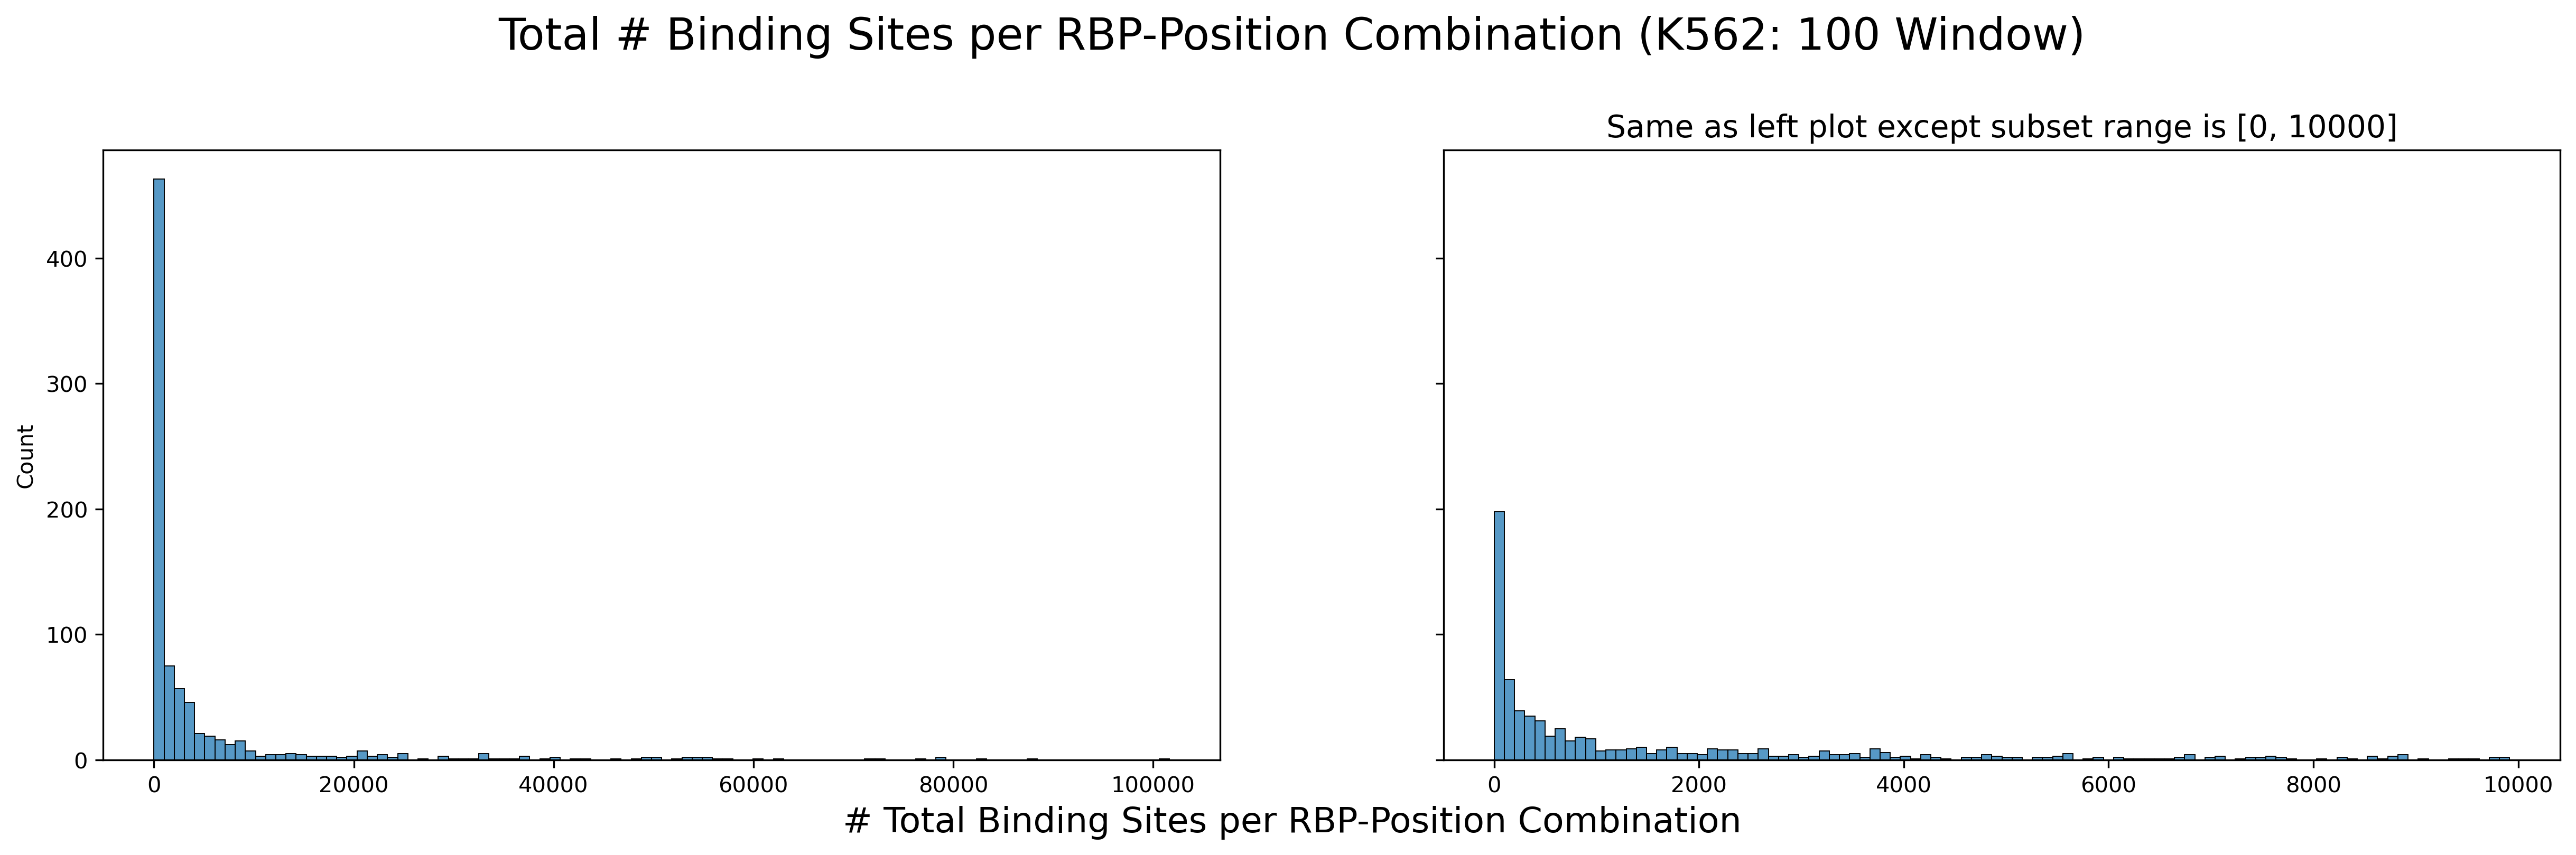

In [9]:
# max value to shown on histogram 
hist_max_value = 10000

# for each cell line and window size 
for cell_line in num_binding_sites: 
    for window_size in num_binding_sites[cell_line]: 
        
        tmp_num_binding_sites = num_binding_sites[cell_line][window_size]
        
        # create 2 subplots 
        fig, ax = plt.subplots(1, 2, figsize=(20,5), dpi=300, sharey=True)
        
        # first histogram plot uses the entirety of the data 
        # due to severe skewdness, the 2nd plot subsets the x axis by a lot 
        sns.histplot(tmp_num_binding_sites, bins=100, ax=ax[0])
        sns.histplot(tmp_num_binding_sites[tmp_num_binding_sites.between(0,hist_max_value)], bins=100, ax=ax[1])
        
        _=plt.suptitle("Total # Binding Sites per RBP-Position Combination ({}: {} Window)".format(cell_line, window_size), fontsize=20, y=1.05)
        _=ax[1].set_title("Same as left plot except subset range is [0, {}]".format(hist_max_value), fontsize=14)
        
        _=fig.supxlabel("# Total Binding Sites per RBP-Position Combination", fontsize=16)
        
        plt.show()

#### Heatmap + ClusterMap w/ matrix of dimension (# RBPs, 6)

In [10]:
rbp_by_position_matrix = {}

# for each cell line and window size 
for cell_line in num_binding_sites: 
    rbp_by_position_matrix[cell_line] = {}
    
    for window_size in num_binding_sites[cell_line]: 
        
        tmp_num_binding_sites = num_binding_sites[cell_line][window_size]
        
        # create a dictionary for this combination of cell line and window size which will be turned into a DataFrame
        # {"rbp": {"position": "value"}}
        num_binding_sites_df = {}
        
        # for each RBP-position combination and number of total binding sites
        for index, value in tmp_num_binding_sites.items(): 
            
            # for each position in a skipped exon 
            for position_string in splice_junction_position_renaming:
                
                # if position in RBP-position combination matches the "position_string"
                if position_string in index: 
                    # get rbp and position 
                    rbp = index.split("_")[0]
                    position = splice_junction_position_renaming[position_string]
                    
                    # if rbp not already in dictionary, then add it 
                    if rbp not in num_binding_sites_df: 
                        num_binding_sites_df[rbp] = {}
                    
                    # separate out the position and RBP into 2 dimensions
                    num_binding_sites_df[rbp][position] = value
                    
                    # end the innermost loop if you've already found the correct position 
                    break
        
        # from dictionary, convert to DataFrame where the rows are a given position and each column is an RBP 
        num_binding_sites_df = pd.DataFrame.from_dict(num_binding_sites_df, orient="columns")
        num_binding_sites_df.shape

        rbp_by_position_matrix[cell_line][window_size] = num_binding_sites_df

(6, 105)

(6, 139)

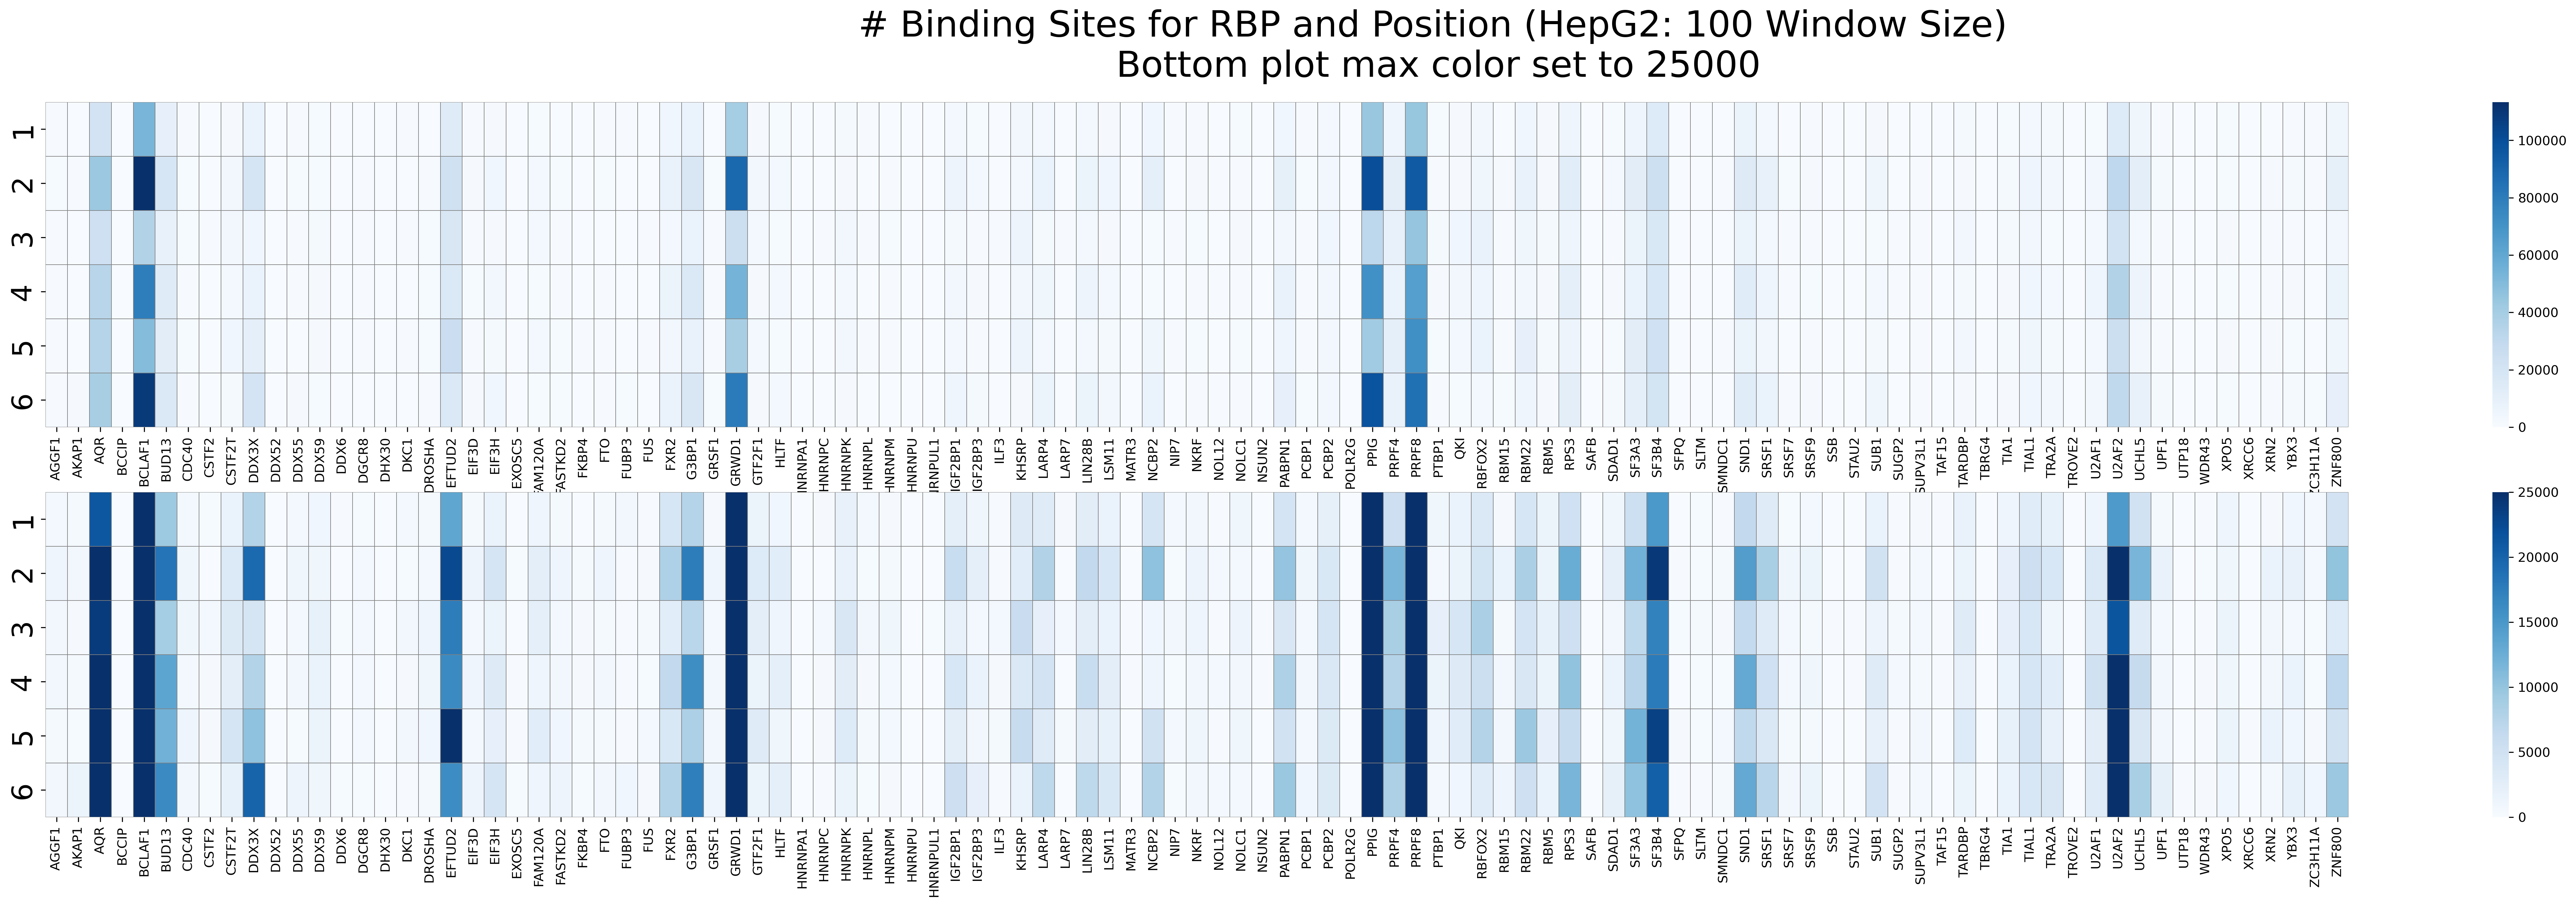

Text(0.5, 0.98, 'HepG2: 100 Window Size')

Text(0.5, 1.05, 'HepG2: 100 Window Size \n(Max color set to 25000)')

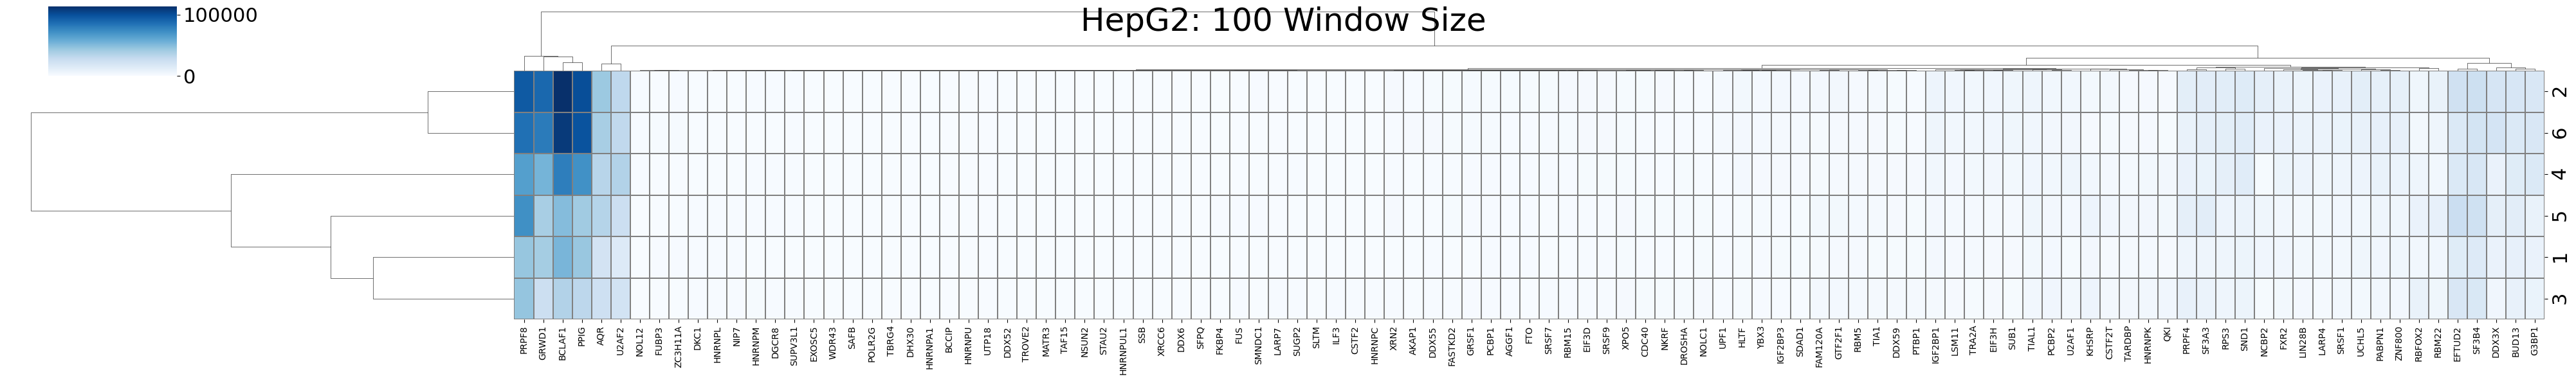

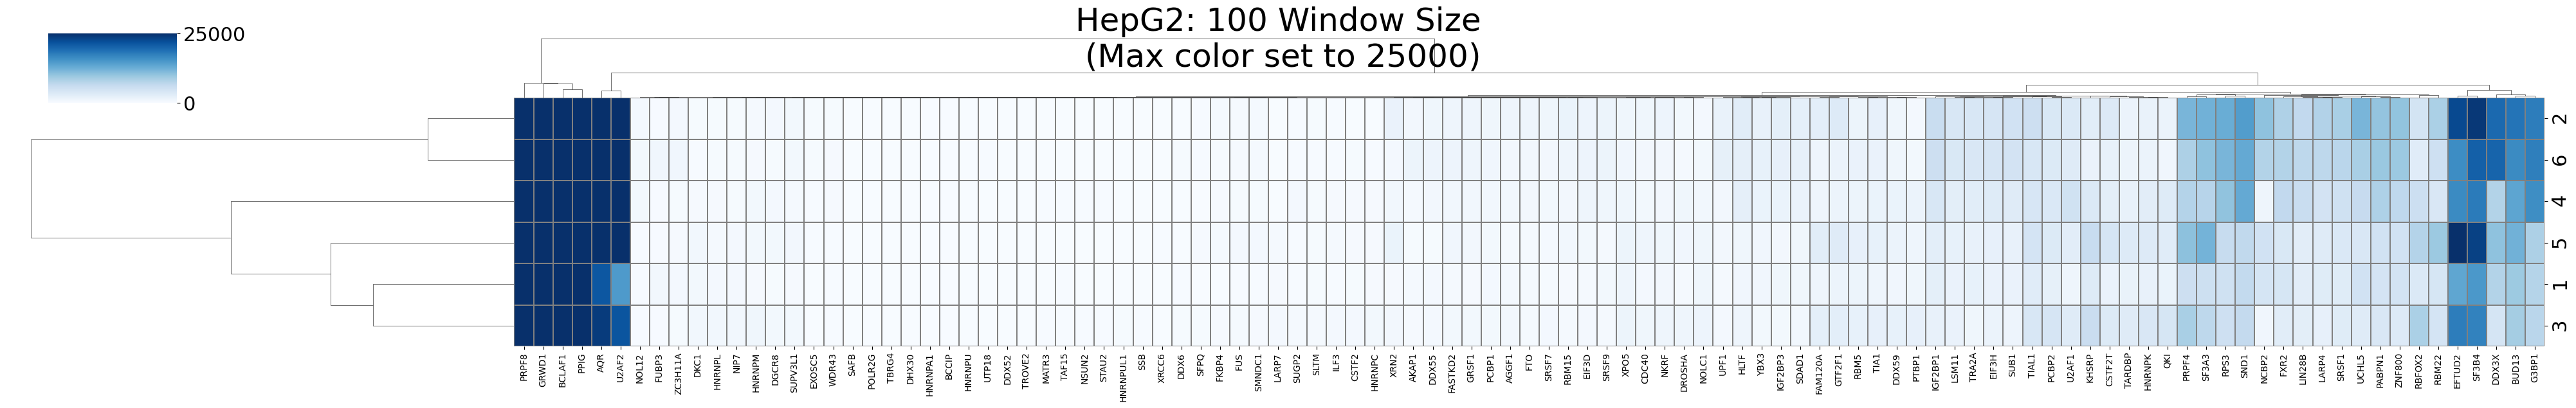

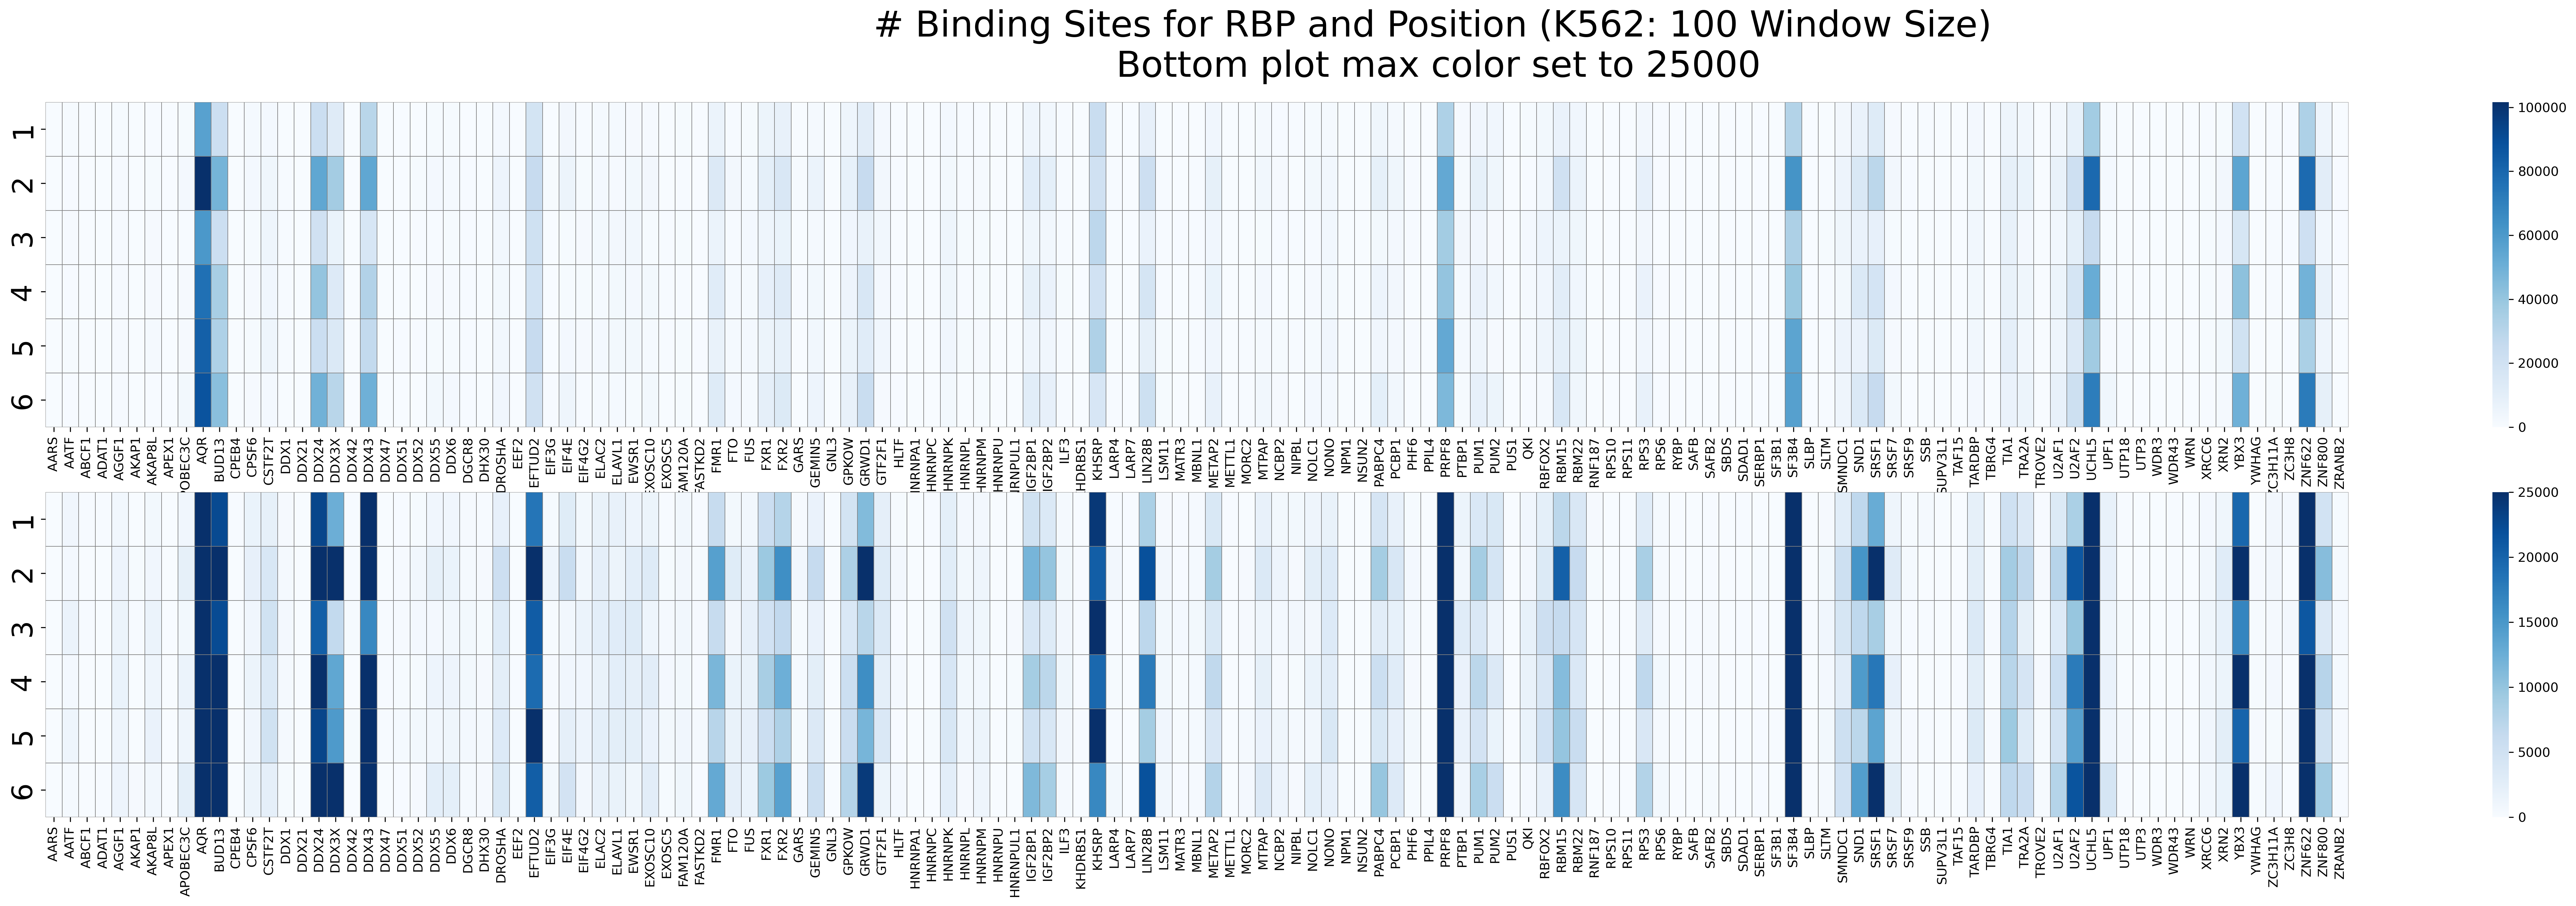

Text(0.5, 0.98, 'K562: 100 Window Size')

Text(0.5, 1.05, 'K562: 100 Window Size \n(Max color set to 25000)')

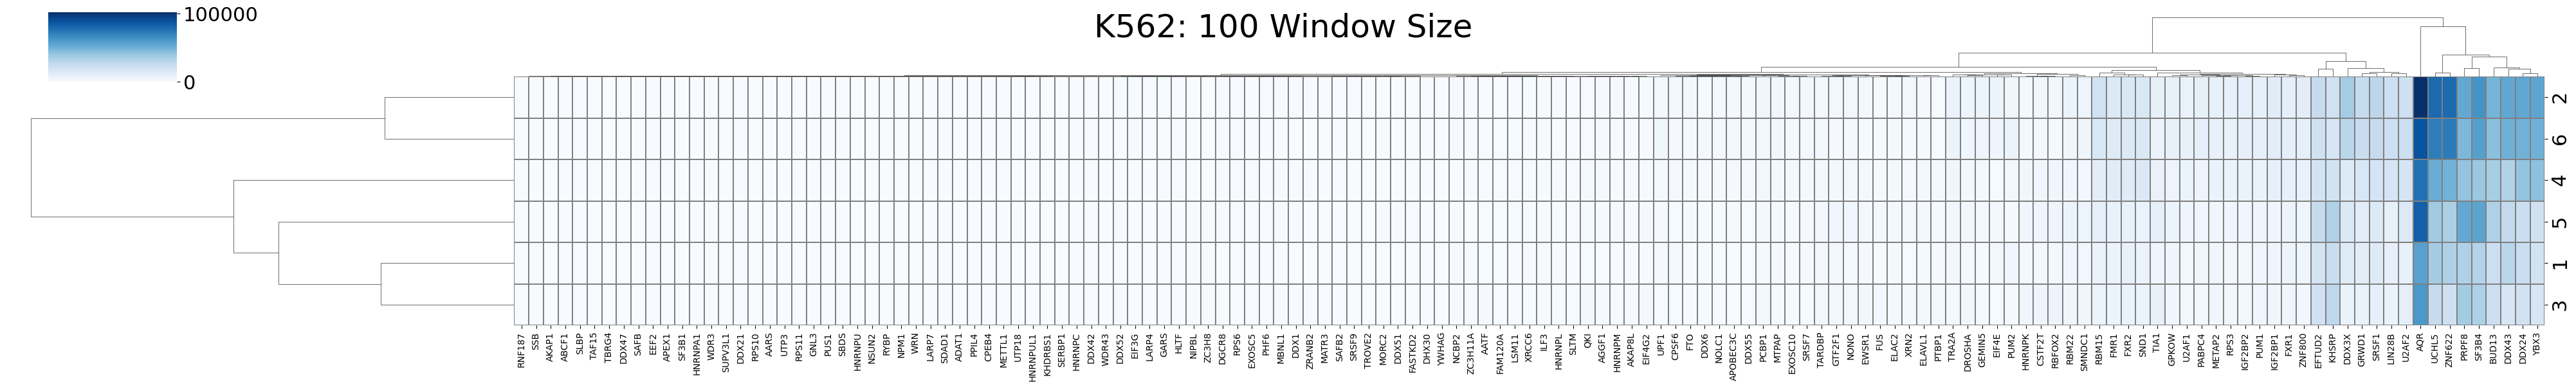

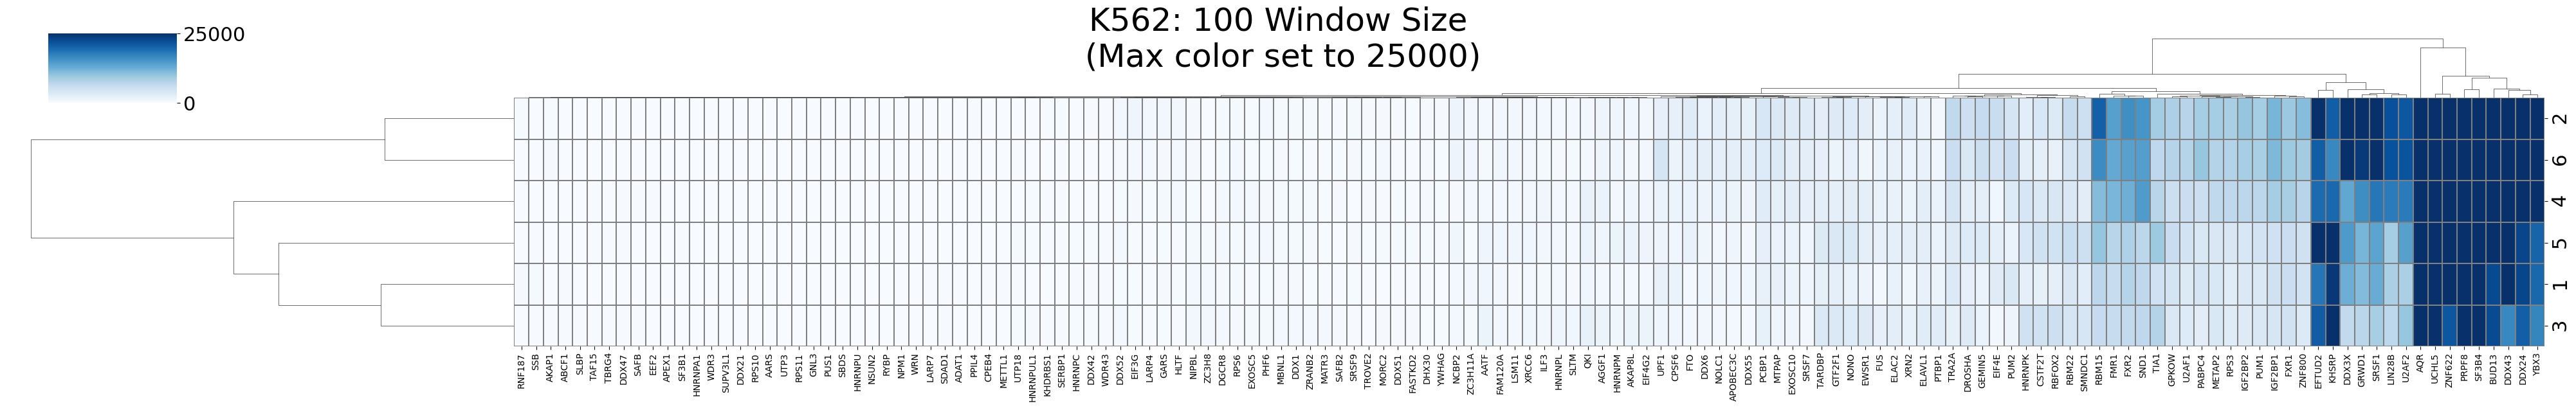

In [11]:
# for each cell line and window size 
for cell_line in num_binding_sites: 
    for window_size in num_binding_sites[cell_line]: 
        
        num_binding_sites_df = rbp_by_position_matrix[cell_line][window_size]
        
        # create two subplots vertically 
        fig, ax =plt.subplots(2, 1, dpi=300, figsize=(40, 10))
        _=plt.suptitle("# Binding Sites for RBP and Position ({}: {} Window Size) \nBottom plot max color set to {}".format(cell_line, window_size, max_heatmap_value), fontsize=28)
        
        # first subplot is with all the values 
        # second subplot caps the maximum value color due to the outliers dominating the max color 
        plot1= sns.heatmap(num_binding_sites_df, linewidths=0.1, linecolor="gray", ax=ax[0], cmap="Blues")
        plot2= sns.heatmap(num_binding_sites_df, linewidths=0.1, linecolor="gray", vmin=0, vmax=25000, ax=ax[1], cmap="Blues")
        
        plot1.tick_params(axis="y", labelsize=22)
        plot2.tick_params(axis="y", labelsize=22)
    
        plt.show()
        
        # now create two clustermaps where the only difference between both of them 
        # is that the first clustermap doesn't have a limit to the max color and the second one does 
        plot=sns.clustermap(num_binding_sites_df, figsize=(40, 6), linewidths=0.1, linecolor="gray", cmap="Blues")
        plot.fig.suptitle("{}: {} Window Size".format(cell_line, window_size), fontsize=36,)
        plot.tick_params(axis="y", labelsize=22)

        plot=sns.clustermap(num_binding_sites_df, figsize=(40, 6), linewidths=0.1, linecolor="gray", vmin=0, vmax=25000, cmap="Blues")
        plot.fig.suptitle("{}: {} Window Size \n(Max color set to {})".format(cell_line, window_size, max_heatmap_value), fontsize=36, y=1.05)
        plot.tick_params(axis="y", labelsize=22)
        
        plt.show()
        

## What is the Distribution of the % of RBP-Position Combinations Bound per `SE` Event?

<Axes: ylabel='Percent'>

<Axes: ylabel='Percent'>

[Text(0.5, 0, 'Number of RBP-Position Combinations Bound')]

[Text(0.5, 0, '% of RBP-Position Combinations Bound')]

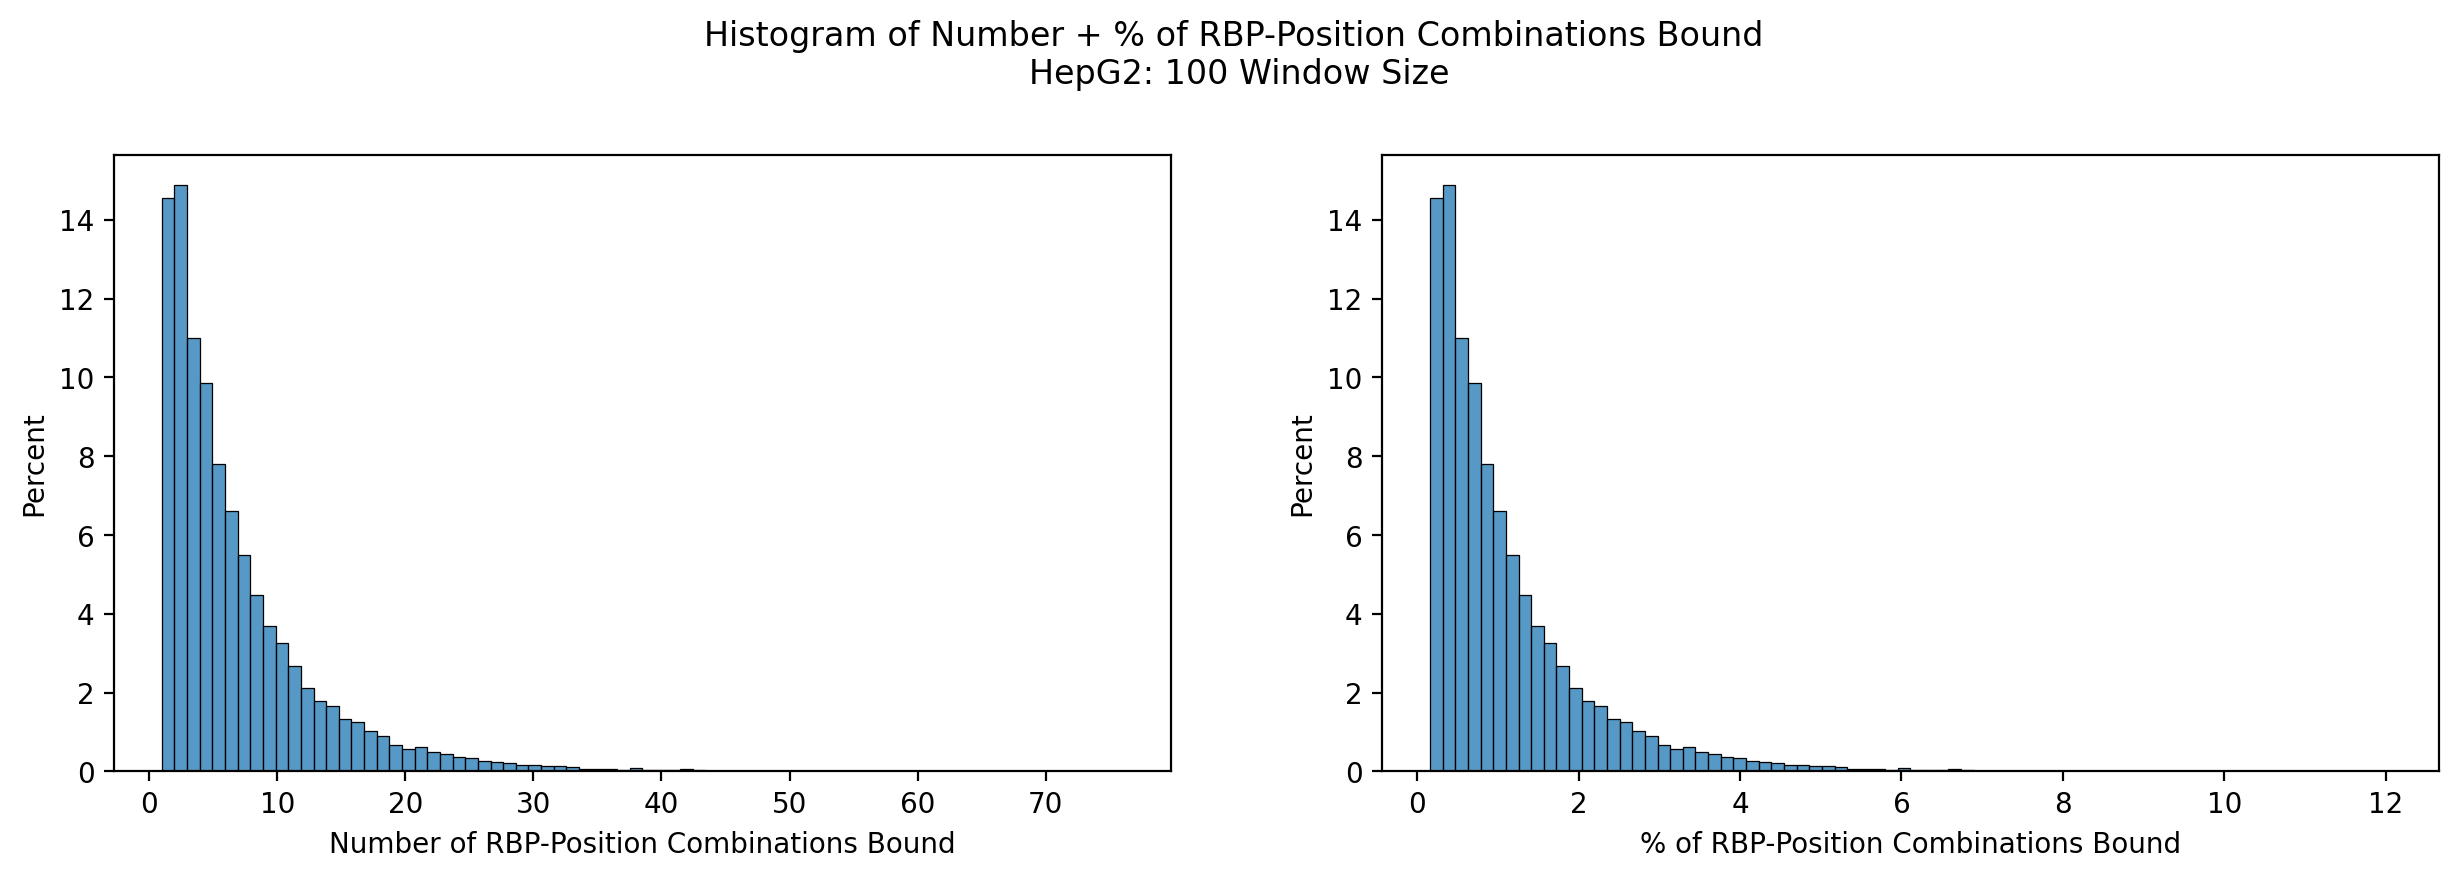

<Axes: ylabel='Percent'>

<Axes: ylabel='Percent'>

[Text(0.5, 0, 'Number of RBP-Position Combinations Bound')]

[Text(0.5, 0, '% of RBP-Position Combinations Bound')]

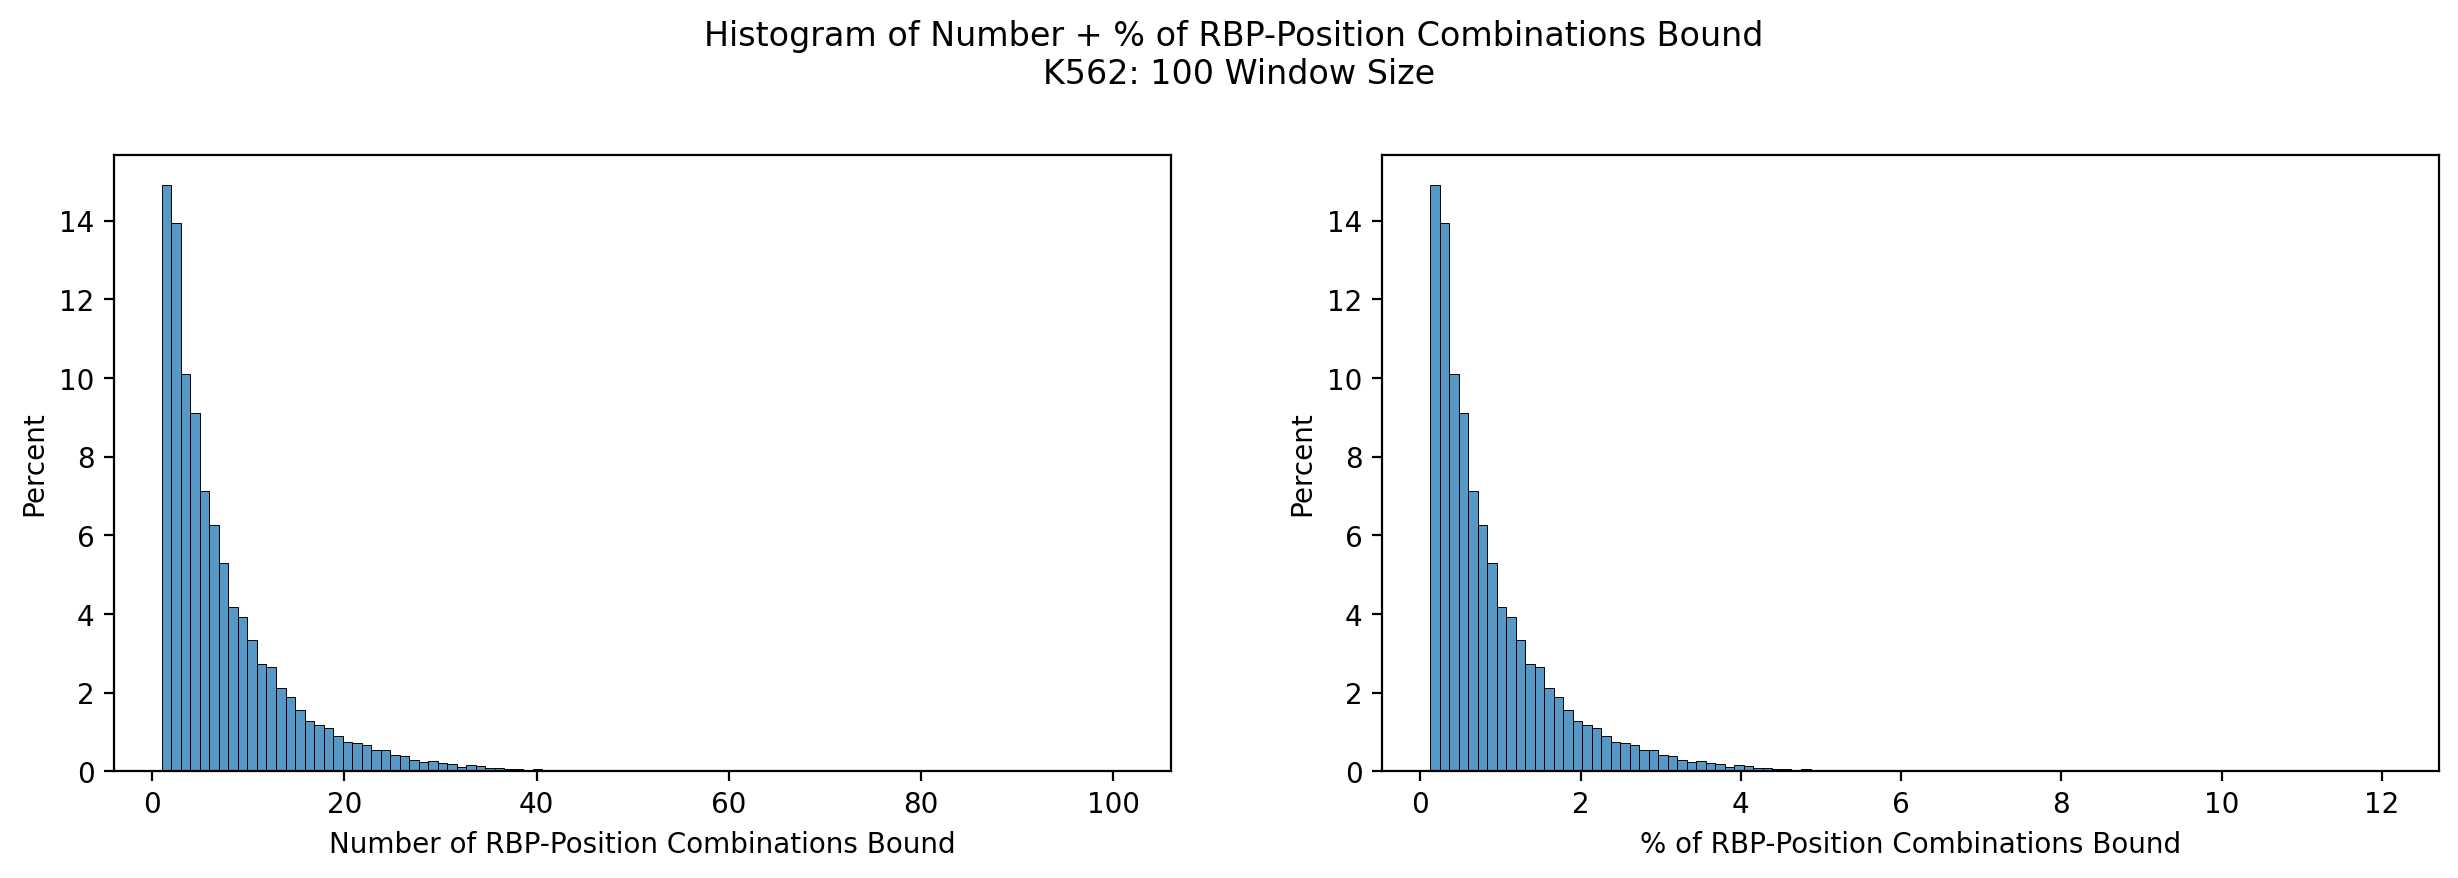

In [12]:
for cell_line in all_binding_data: 
    for window_size in all_binding_data[cell_line]:

        total_binding = all_binding_data[cell_line][window_size].sum(axis=1)
        percent_binding = ((all_binding_data[cell_line][window_size].sum(axis=1))/ len(all_binding_data[cell_line][window_size].columns))*100
                
        fig, ax = plt.subplots(1,2, dpi=200, figsize=(15,4))
        sns.histplot(
            total_binding,
            bins=total_binding.max(), 
            stat="percent",
            ax=ax[0]
        )
        sns.histplot(
            percent_binding,
            bins=total_binding.max(),
            stat="percent",
            ax=ax[1]
        )
        
        _=plt.suptitle("Histogram of Number + % of RBP-Position Combinations Bound \n{}: {} Window Size".format(cell_line, window_size), y=1.05)
        ax[0].set(xlabel="Number of RBP-Position Combinations Bound")  
        ax[1].set(xlabel="% of RBP-Position Combinations Bound")  

        plt.show()

#### There are no events with 0 RBPs Binding!

#### Looks like Ayan has filtered those out. 

## Do RBPs Binding to `SE` Events Prefer Certain Positions?

NOTE: `Z-Scoring` columns that have only "0" as a value means they turn into "NaN" and are masked in certain visualizations.

Each plot below is sorted by one of the 6 positions to look for patterns

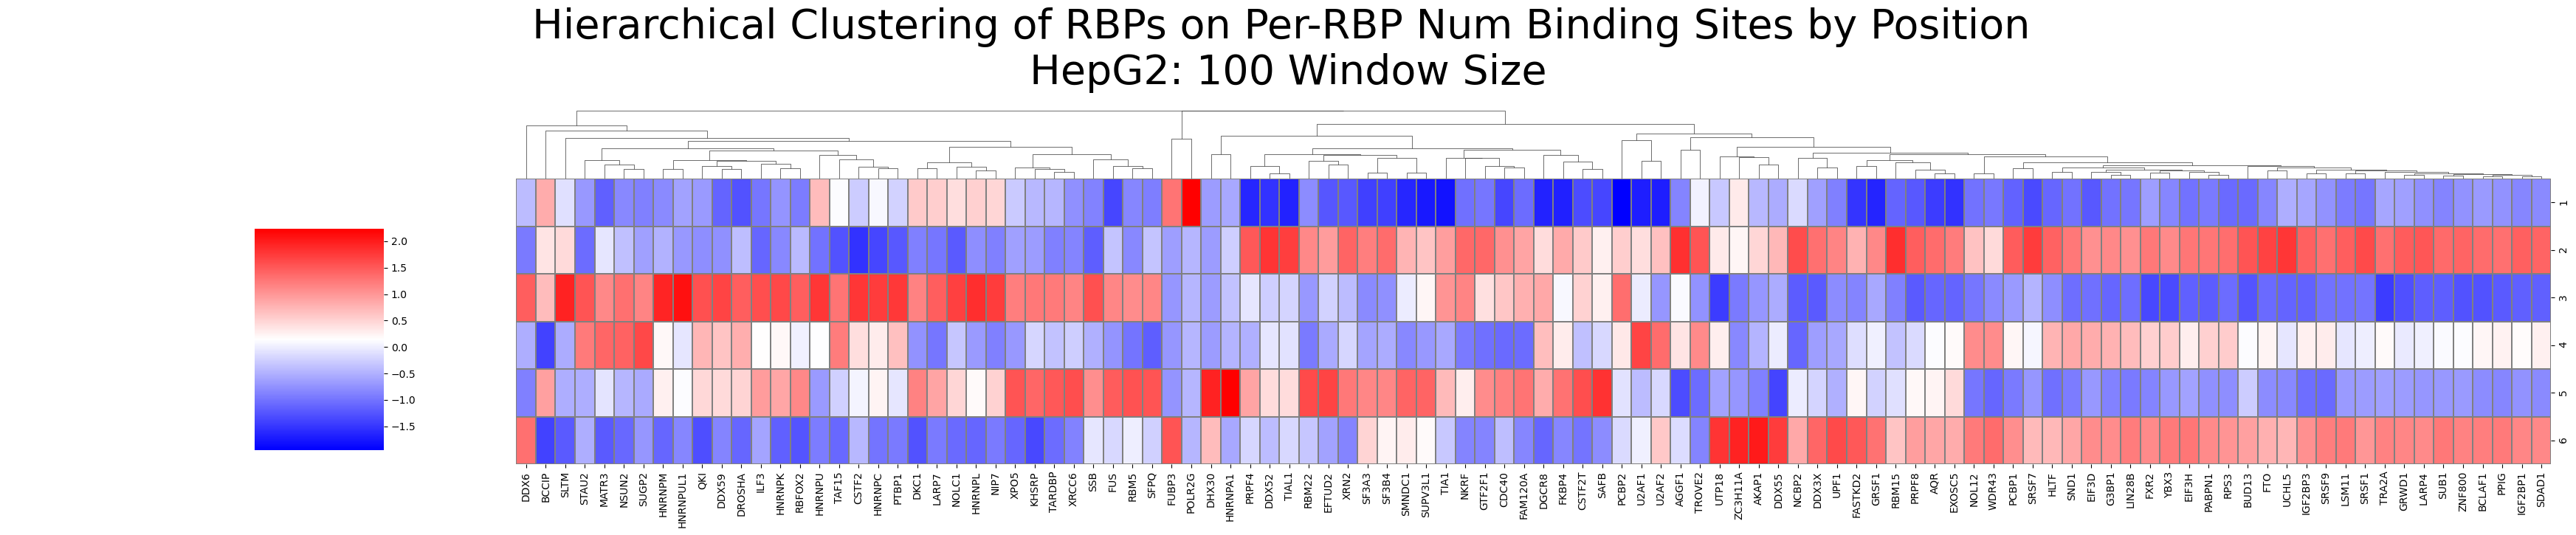

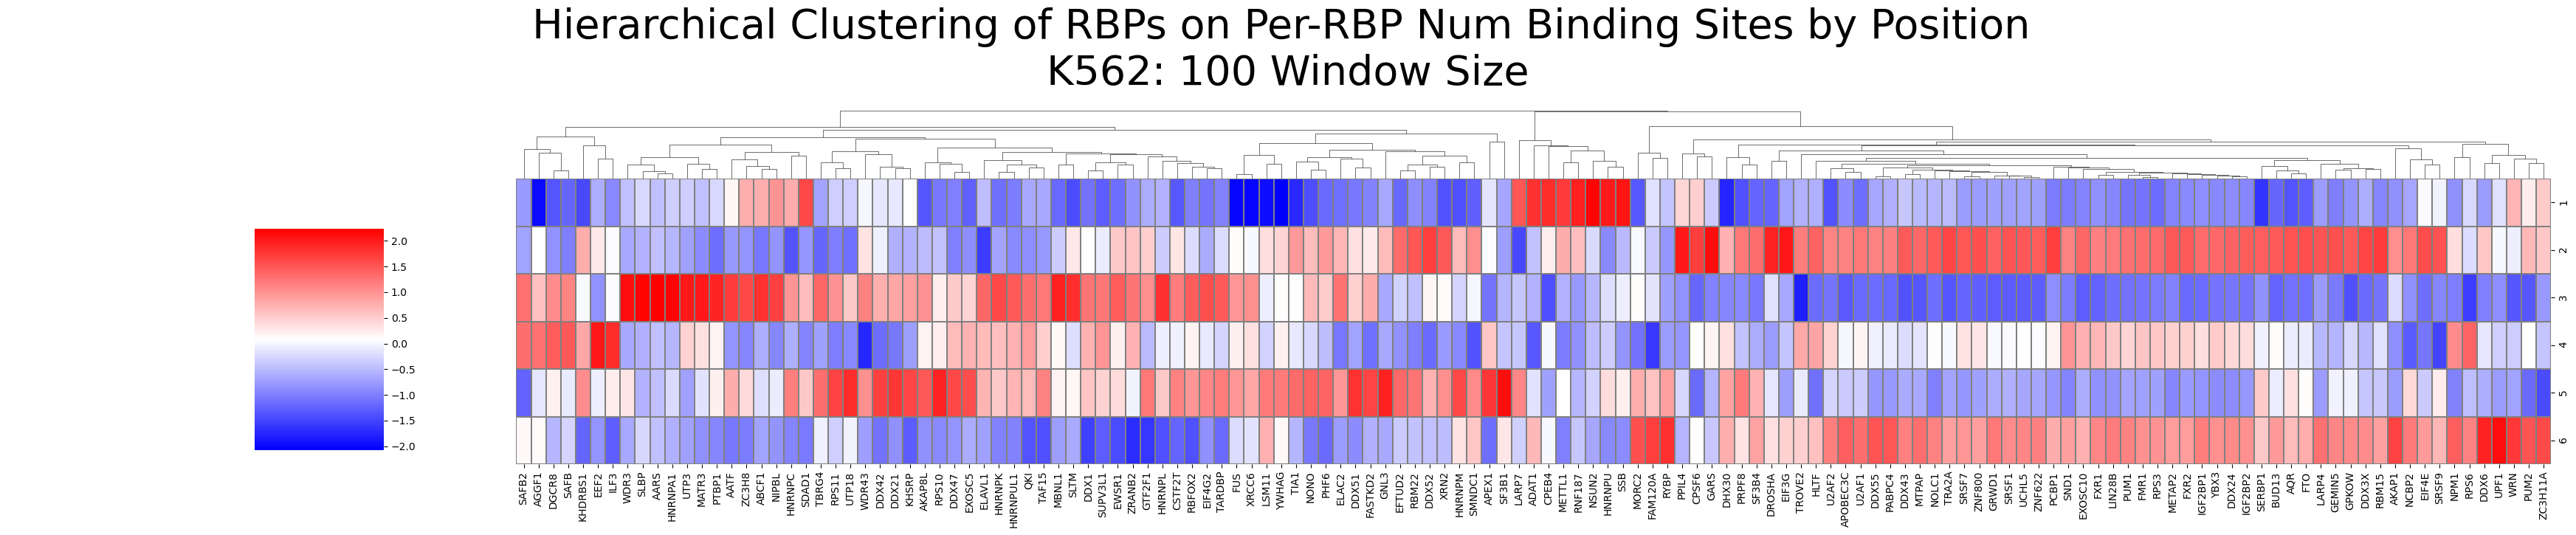

In [13]:
for cell_line in num_binding_sites: 
    for window_size in num_binding_sites[cell_line]: 

        num_binding_sites_df = rbp_by_position_matrix[cell_line][window_size]
        
        # z score normalize the columns (meaning that each RBP's values at 6 positions are z-scored) 
        # NOTE: columns with no variance become NaN
        num_binding_sites_df = num_binding_sites_df.apply(scipy.stats.zscore, axis="index", nan_policy="raise")  
        
        # remove columns that have NaN values after z score transformation 
        num_binding_sites_df = num_binding_sites_df.dropna(axis="columns", how="all")
                                
        # create clustermap but do not cluster by row as we want to see how the RBPs cluster by positions 
        sns.clustermap(
            num_binding_sites_df, 
            figsize=(35, 6), 
            linewidths=0.1, 
            linecolor="gray", 
            cmap="bwr", 
            row_cluster=False, 
            cbar_pos=(0.1, 0.2, 0.05, 0.5), 
        )
        
        _=plt.suptitle("Hierarchical Clustering of RBPs on Per-RBP Num Binding Sites by Position \n{}: {} Window Size".format(cell_line, window_size), fontsize=40, y=1.2)

        plt.show()
        

## How Similar Are the Position Preferences of RBPs Between Cell Lines?

Can answer this by looking at how Hierarchical Clusterings (from above) compare between Cell Lines. 

* Need to look at BOTH:
    * RBPs profiled in both cell lines WHERE:
        * Both RBPs remain after `Z-Score Transformation` as RBPs with all "0" values are removed

In [14]:
# take the intersection of the RBPs left after Z scores between each cell line for each window size 
both_cell_line_profiled_rbps = {}

# can do this as the window sizes are same for both cell lines 
for window_size in rbp_by_position_matrix["K562"]: 

    similar_rbps = []
    
    for cell_line in ["K562", "HepG2"]: 

        num_binding_sites_df = rbp_by_position_matrix[cell_line][window_size]
        
        # z score normalize the columns (meaning that each RBP's values at 6 positions are z-scored) 
        # NOTE: columns with no variance become NaN
        num_binding_sites_df = num_binding_sites_df.apply(scipy.stats.zscore, axis="index", nan_policy="raise")  
        
        # remove columns that have NaN values after z score transformation 
        num_binding_sites_df = num_binding_sites_df.dropna(axis="columns", how="all")

        similar_rbps.append(set(num_binding_sites_df.columns.unique()))

    both_cell_line_profiled_rbps[window_size] = similar_rbps[0].intersection(similar_rbps[1])

In [15]:
for window_size in both_cell_line_profiled_rbps: 
    len(both_cell_line_profiled_rbps[window_size])
    print(both_cell_line_profiled_rbps[window_size])

75

{'ILF3', 'ZC3H11A', 'RBFOX2', 'GRWD1', 'EFTUD2', 'GTF2F1', 'SAFB', 'DGCR8', 'XRN2', 'DDX55', 'PRPF8', 'SF3B4', 'FAM120A', 'FASTKD2', 'TARDBP', 'TIA1', 'XRCC6', 'WDR43', 'HNRNPC', 'HNRNPL', 'HNRNPU', 'CSTF2T', 'SRSF7', 'PCBP1', 'LARP4', 'SRSF1', 'SRSF9', 'SND1', 'SDAD1', 'BUD13', 'DDX52', 'SMNDC1', 'FTO', 'HNRNPK', 'IGF2BP1', 'MATR3', 'FXR2', 'LARP7', 'LSM11', 'FUS', 'LIN28B', 'RPS3', 'NOLC1', 'DROSHA', 'KHSRP', 'HLTF', 'HNRNPA1', 'ZNF800', 'QKI', 'HNRNPM', 'TROVE2', 'HNRNPUL1', 'NSUN2', 'EXOSC5', 'AQR', 'U2AF1', 'YBX3', 'DHX30', 'UCHL5', 'AGGF1', 'DDX6', 'SLTM', 'U2AF2', 'RBM22', 'UTP18', 'PTBP1', 'RBM15', 'NCBP2', 'UPF1', 'AKAP1', 'SUPV3L1', 'SSB', 'DDX3X', 'TRA2A', 'TAF15'}


In [16]:
z_scored_matrices = {}

for window_size in both_cell_line_profiled_rbps: 
    z_scored_matrices[window_size] = {}
    
    for cell_line in ["K562", "HepG2"]: 

        num_binding_sites_df = rbp_by_position_matrix[cell_line][window_size]
          
        # z score normalize the columns (meaning that each RBP's values at 6 positions are z-scored) 
        # NOTE: columns with no variance become NaN
        num_binding_sites_df = num_binding_sites_df.apply(scipy.stats.zscore, axis="index", nan_policy="raise")  
        
        # remove columns that have NaN values after z score transformation 
        num_binding_sites_df = num_binding_sites_df.dropna(axis="columns", how="all")

        # subset only to those columns that are same between both cell lines 

        z_scored_matrices[window_size][cell_line] = num_binding_sites_df[list(both_cell_line_profiled_rbps[window_size])]


<Figure size 3200x2400 with 0 Axes>

<Figure size 3200x2400 with 0 Axes>

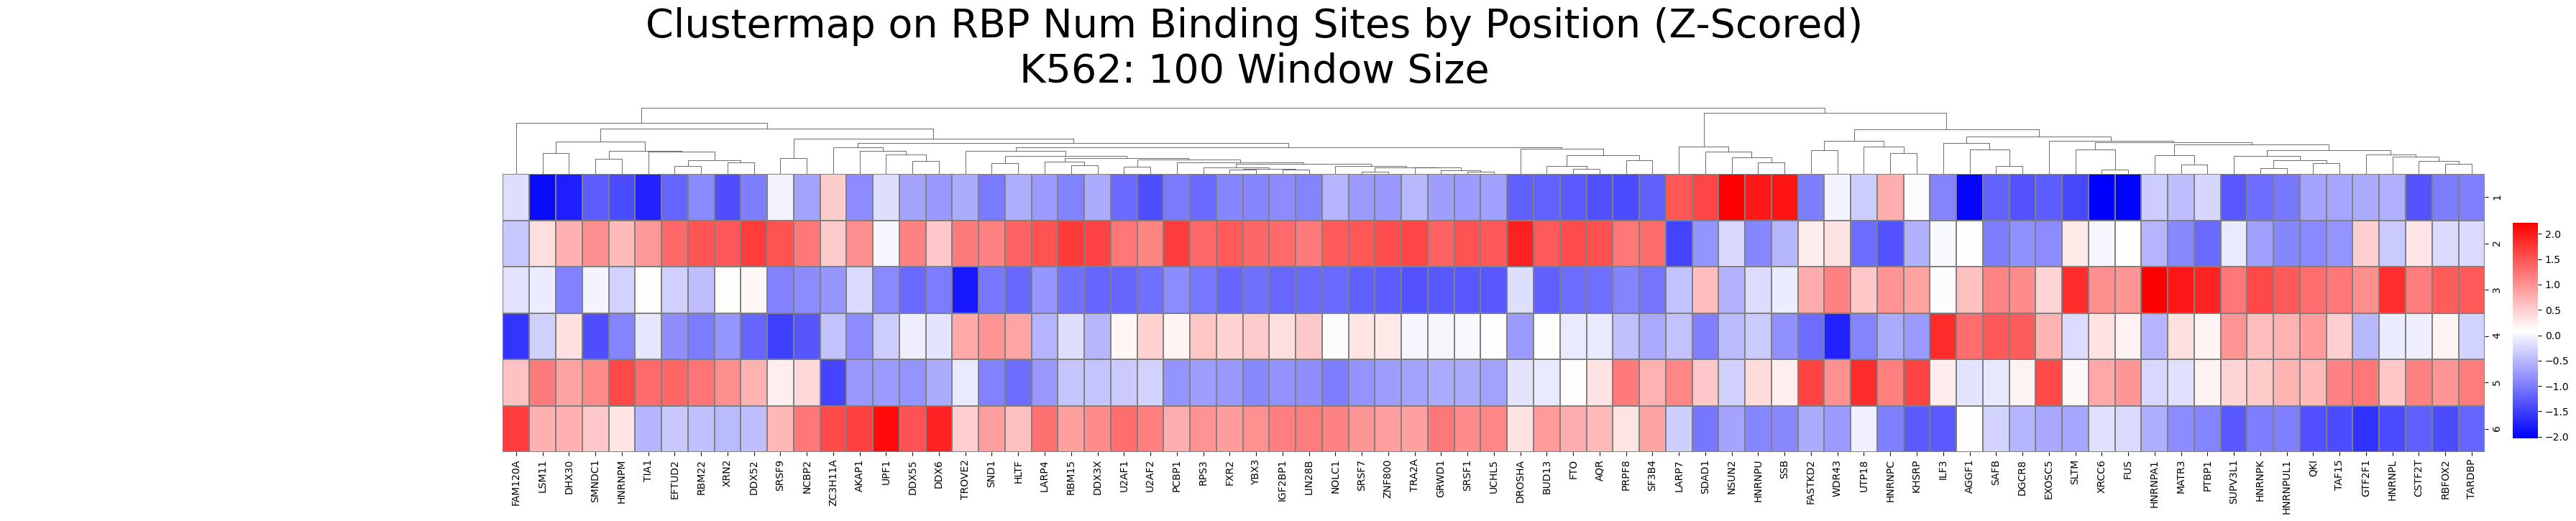

<Figure size 4000x400 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Heatmap of HepG2-100 window size matching K562')

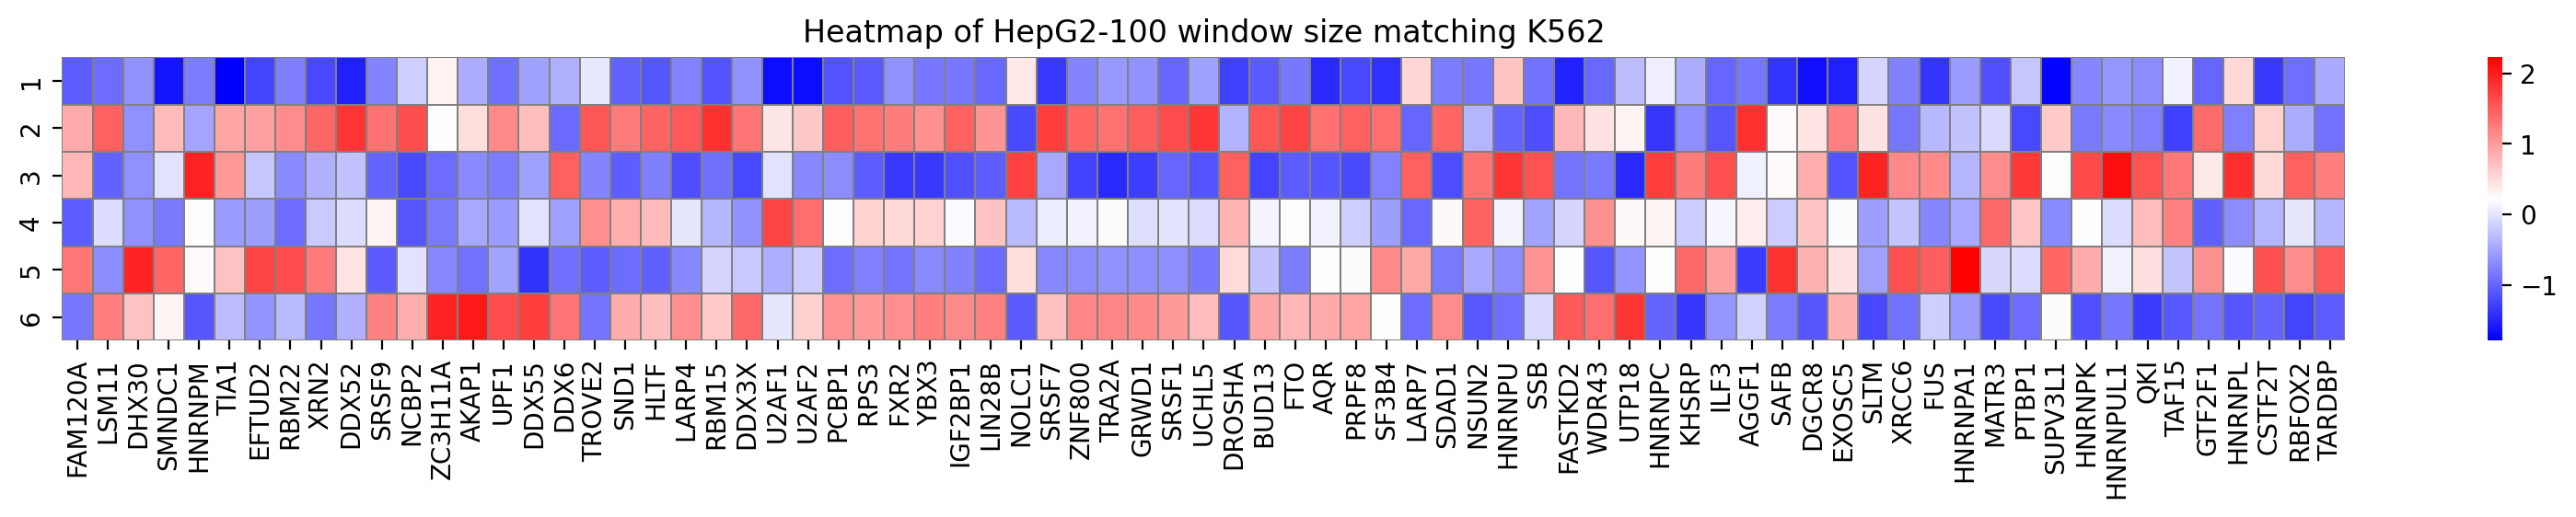

<Figure size 3200x2400 with 0 Axes>

<Figure size 3200x2400 with 0 Axes>

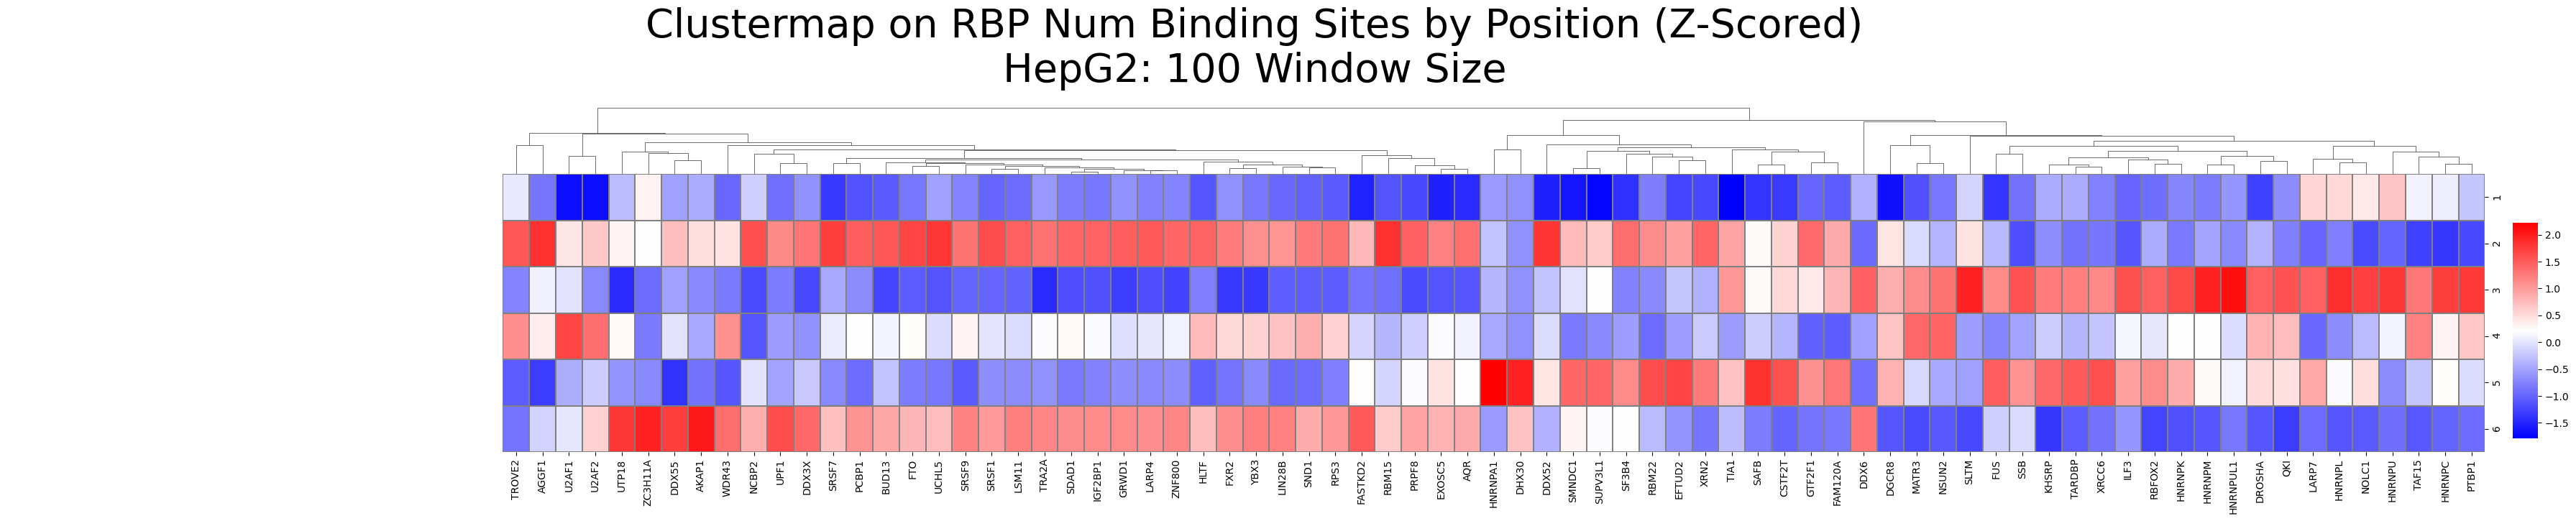

<Figure size 4000x400 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Heatmap of K562-100 window size matching HepG2')

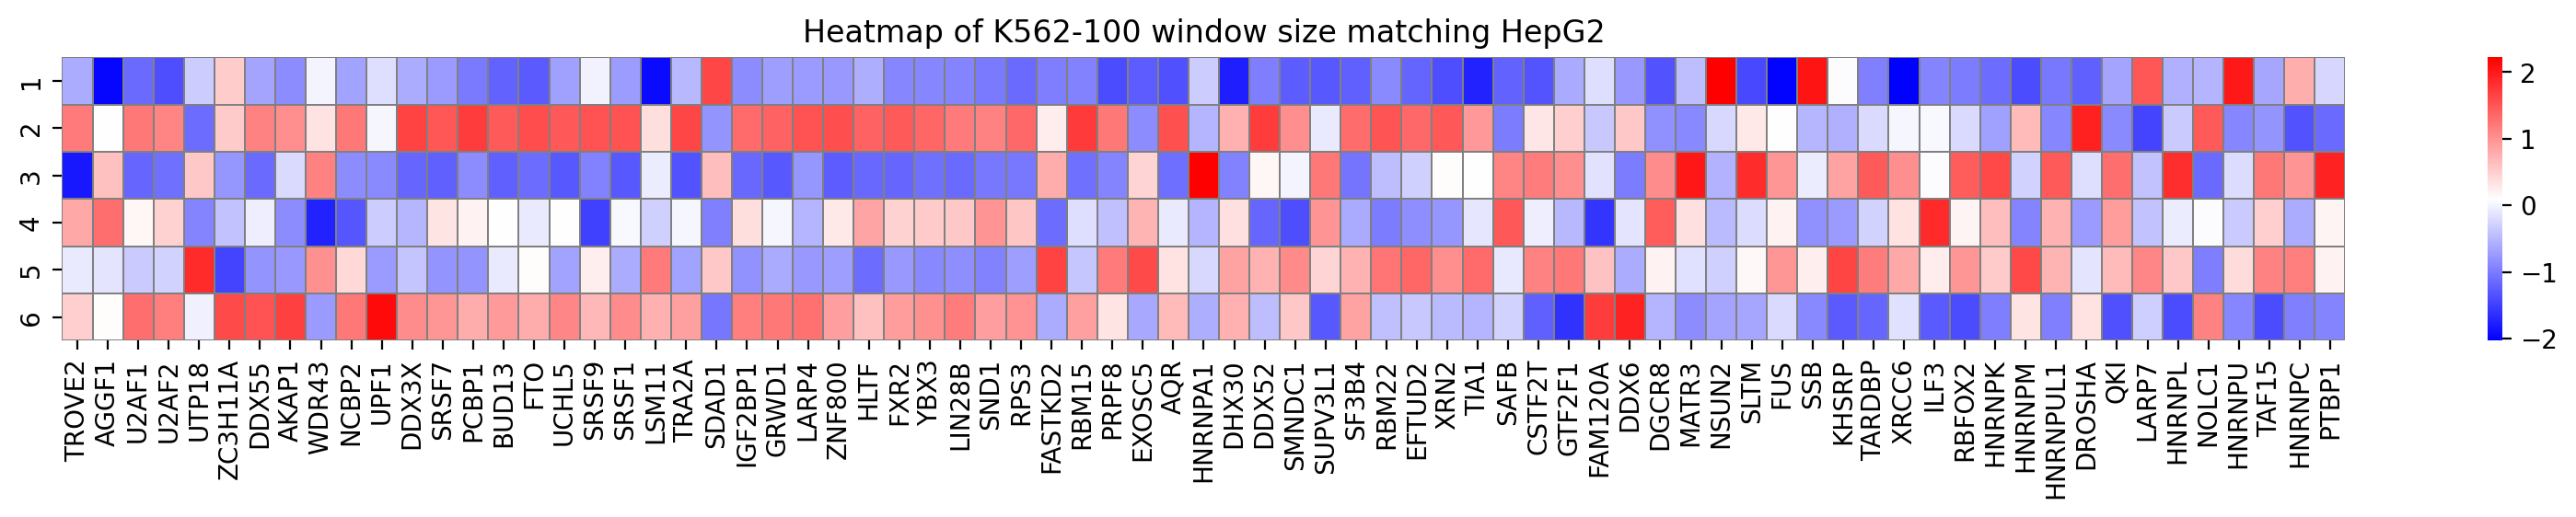

In [17]:
for window_size in z_scored_matrices:

    plt.figure(dpi=500)
    # create clustermap but do not cluster by row as we want to see how the RBPs cluster by positions 
    cluster_map = sns.clustermap(
        z_scored_matrices[window_size]["K562"], 
        figsize=(35, 6), 
        linewidths=0.1, 
        linecolor="gray", 
        cmap="bwr", 
        row_cluster=False, 
        cbar_pos=(1, 0.2, 0.01, 0.5)
    )
    
    _=plt.suptitle("Clustermap on RBP Num Binding Sites by Position (Z-Scored)\n{}: {} Window Size".format("K562", window_size), fontsize=40, y=1.2)

    plt.show()

    k562_label_order = [t.get_text() for t in cluster_map.ax_heatmap.xaxis.get_majorticklabels()]

    hepg2_heatmap = z_scored_matrices[window_size]["HepG2"][k562_label_order]

    plt.figure(dpi=200, figsize=(20,2))

    sns.heatmap(
        hepg2_heatmap,
        linewidths=0.1, 
        linecolor="gray", 
        cmap="bwr", 
    )

    plt.title("Heatmap of HepG2-{} window size matching K562".format(window_size))

    plt.show()

#################################################################################################################################################
# VICE VERSA 

    plt.figure(dpi=500)
    # create clustermap but do not cluster by row as we want to see how the RBPs cluster by positions 
    cluster_map = sns.clustermap(
        z_scored_matrices[window_size]["HepG2"], 
        figsize=(35, 6), 
        linewidths=0.1, 
        linecolor="gray", 
        cmap="bwr", 
        row_cluster=False, 
        cbar_pos=(1, 0.2, 0.01, 0.5)
    )
    
    _=plt.suptitle("Clustermap on RBP Num Binding Sites by Position (Z-Scored)\n{}: {} Window Size".format("HepG2", window_size), fontsize=40, y=1.2)

    plt.show()

    hepg2_label_order = [t.get_text() for t in cluster_map.ax_heatmap.xaxis.get_majorticklabels()]

    k562_heatmap = z_scored_matrices[window_size]["K562"][hepg2_label_order]

    plt.figure(dpi=200, figsize=(20,2))

    sns.heatmap(
        k562_heatmap,
        linewidths=0.1, 
        linecolor="gray", 
        cmap="bwr", 
    )

    plt.title("Heatmap of K562-{} window size matching HepG2".format(window_size))

    plt.show()
        

### `Tanglegrams` to compare hierarchical clusterings 

In [18]:
k562_position_preference_distances = pd.DataFrame(
    scipy.spatial.distance.squareform(
        scipy.spatial.distance.pdist(k562_heatmap.T, metric="euclidean")
    ),
    index = k562_heatmap.columns, 
    columns = k562_heatmap.columns
)

k562_position_preference_distances.shape
k562_position_preference_distances.head()

hepg2_position_preference_distances = pd.DataFrame(
    scipy.spatial.distance.squareform(
        scipy.spatial.distance.pdist(hepg2_heatmap.T, metric="euclidean")
    ),
    index = hepg2_heatmap.columns, 
    columns = hepg2_heatmap.columns
)

hepg2_position_preference_distances.shape
hepg2_position_preference_distances.head()

(75, 75)

,TROVE2,AGGF1,U2AF1,U2AF2,UTP18,ZC3H11A,DDX55,AKAP1,WDR43,NCBP2,UPF1,DDX3X,SRSF7,PCBP1,BUD13,FTO,UCHL5,SRSF9,SRSF1,LSM11,TRA2A,SDAD1,IGF2BP1,GRWD1,LARP4,ZNF800,HLTF,FXR2,YBX3,LIN28B,SND1,RPS3,FASTKD2,RBM15,PRPF8,EXOSC5,AQR,HNRNPA1,DHX30,DDX52,SMNDC1,SUPV3L1,SF3B4,RBM22,EFTUD2,XRN2,TIA1,SAFB,CSTF2T,GTF2F1,FAM120A,DDX6,DGCR8,MATR3,NSUN2,SLTM,FUS,SSB,KHSRP,TARDBP,XRCC6,ILF3,RBFOX2,HNRNPK,HNRNPM,HNRNPUL1,DROSHA,QKI,LARP7,HNRNPL,NOLC1,HNRNPU,TAF15,HNRNPC,PTBP1
TROVE2,0.000000,3.072691,1.350852,1.323479,4.262253,2.705809,1.658712,2.708497,4.367401,2.487730,2.614951,1.673352,1.195483,1.526474,1.229173,1.418056,1.268644,2.585089,1.251599,2.927008,1.256702,4.566984,1.304130,1.323803,2.023050,1.137382,1.256629,1.155476,1.285514,1.294687,1.319071,1.289342,3.973531,1.467127,2.165115,3.730175,1.483162,4.728837,1.882692,3.140159,3.148910,3.851867,1.954662,2.825585,2.872622,3.028360,3.002193,3.851452,3.934950,4.060338,3.622437,2.080650,3.797886,4.608245,3.819349,4.161506,3.592123,4.207973,4.403788,4.310506,3.610986,3.053309,4.226759,4.272037,3.043301,4.266361,2.473297,4.245755,4.115876,4.513692,1.514359,4.168435,4.278010,4.670278,4.698367
AGGF1,3.072691,0.000000,2.813936,2.482441,3.619813,3.907416,3.187550,3.217242,3.931232,3.657246,3.539795,3.430807,3.007508,2.802245,2.821382,2.845633,3.148553,4.068903,3.158732,2.285947,3.310101,4.542358,2.889753,3.165869,3.252329,3.024175,2.873067,2.825693,2.764370,2.758397,2.463196,2.571488,3.254614,3.081899,2.957685,2.298875,2.803516,3.082747,2.269891,3.310744,3.240594,1.807568,3.129250,3.436269,3.163892,2.919267,2.360411,1.486897,2.436755,3.192558,3.926188,3.139514,1.413239,2.672478,4.773088,2.166326,1.611453,4.762115,3.733417,2.778001,1.437188,1.946194,2.535699,2.100436,3.073922,2.195707,2.978079,2.462783,4.480544,2.859078,3.223582,4.640145,2.715397,4.017657,2.940264
U2AF1,1.350852,2.813936,0.000000,0.428969,4.122406,2.237124,0.728119,1.558256,4.132809,1.760043,1.883619,1.009080,0.755870,0.909837,0.527828,0.831031,0.649739,2.207934,0.646039,2.358013,0.949708,4.750812,0.596021,0.562763,1.025345,0.756784,1.372725,0.725564,0.758815,0.667963,1.101339,0.646643,3.753795,0.777156,1.965954,3.846570,1.047256,4.394516,1.574472,2.845347,2.527560,3.931571,1.409383,2.753452,2.734082,2.788573,2.888854,3.802479,3.872711,4.128593,2.945587,1.084641,3.807059,4.463650,4.241171,3.774928,3.252320,4.529202,4.511468,4.217560,3.263598,3.575383,4.232331,4.201532,2.687490,4.256620,1.827573,4.401740,4.442051,4.455726,0.932601,4.590959,4.422253,4.780748,4.610657
U2AF2,1.323479,2.482441,0.428969,0.000000,4.096346,2.525284,1.083149,1.819832,4.197148,2.042804,2.116414,1.373681,0.947999,1.013053,0.621891,0.897177,0.965446,2.518562,0.964672,2.211812,1.239053,4.826402,0.779495,0.929363,1.369402,0.947998,1.380272,0.808852,0.820372,0.734152,0.959939,0.581130,3.712696,1.032136,1.933724,3.621047,1.047386,4.342412,1.338766,2.895323,2.601064,3.690614,1.519004,2.794725,2.720788,2.747064,2.719204,3.543504,3.707943,4.043840,3.136069,1.327464,3.533525,4.333648,4.388487,3.634562,3.023134,4.651295,4.469468,4.087097,3.021186,3.297169,4.065000,3.998442,2.665798,4.050330,1.924365,4.203880,4.498194,4.334164,1.226280,4.669983,4.248182,4.766538,4.494290
UTP18,4.262253,3.619813,4.122406,4.096346,0.000000,4.371429,4.281206,3.912497,2.106641,3.364975,3.895619,4.146257,4.457983,4.418388,4.051201,3.930983,4.360348,3.585738,4.326454,2.576248,4.411500,2.582015,4.412203,4.298675,4.207050,4.432081,4.675269,4.448063,4.475168,4.423522,4.514806,4.378372,1.665520,4.192101,3.098052,2.029116,3.801552,2.826250,3.323932,3.178316,2.651513,3.119154,3.395558,2.966088,2.818808,3.006304,2.774199,3.289141,2.488047,2.463445,2.474296,3.993768,3.160726,2.950873,3.698922,2.951578,2.581845,3.133875,1.501212,2.065277,2.672598,3.727133,2.447419,2.658894,2.274564,2.516974,3.863702,2.705616,2.298036,2.577709,4.479129,3.062184,2.265078,1.704463,2.589287


(75, 75)

,FAM120A,LSM11,DHX30,SMNDC1,HNRNPM,TIA1,EFTUD2,RBM22,XRN2,DDX52,SRSF9,NCBP2,ZC3H11A,AKAP1,UPF1,DDX55,DDX6,TROVE2,SND1,HLTF,LARP4,RBM15,DDX3X,U2AF1,U2AF2,PCBP1,RPS3,FXR2,YBX3,IGF2BP1,LIN28B,NOLC1,SRSF7,ZNF800,TRA2A,GRWD1,SRSF1,UCHL5,DROSHA,BUD13,FTO,AQR,PRPF8,SF3B4,LARP7,SDAD1,NSUN2,HNRNPU,SSB,FASTKD2,WDR43,UTP18,HNRNPC,KHSRP,ILF3,AGGF1,SAFB,DGCR8,EXOSC5,SLTM,XRCC6,FUS,HNRNPA1,MATR3,PTBP1,SUPV3L1,HNRNPK,HNRNPUL1,QKI,TAF15,GTF2F1,HNRNPL,CSTF2T,RBFOX2,TARDBP
FAM120A,0.000000,3.569705,2.756669,1.539515,2.447664,1.214090,1.239266,1.652885,1.570970,2.020755,3.890575,3.134643,4.141700,4.013397,3.491267,4.110796,3.731257,3.761541,3.867662,3.719252,3.644919,2.903268,3.433571,3.517242,3.565992,3.568400,3.743072,3.966238,3.933363,3.701485,3.965289,2.923913,3.164083,3.734081,3.837429,3.693342,3.476579,3.575850,2.498744,3.392191,3.579889,3.077279,3.079434,2.048145,2.578604,3.764790,3.344345,3.590860,2.408228,3.243647,4.229886,4.279595,3.192595,2.007195,2.495985,3.271568,1.354254,1.964697,3.007625,2.466228,1.997970,1.524768,2.043049,3.008910,3.291877,1.444808,2.370285,2.603752,2.760594,3.718605,0.674530,2.793990,0.916479,1.885675,2.074403
LSM11,3.569705,0.000000,3.500682,2.794576,4.350821,3.102018,3.189882,2.952369,2.929816,2.219451,0.586354,1.529497,2.063373,1.472846,0.763934,1.296351,3.531010,2.621732,1.030987,1.060137,0.293142,0.975925,0.865362,2.684282,1.989963,0.555632,0.691898,0.791533,0.800988,0.312685,0.902092,4.791312,0.902892,0.376596,0.632294,0.422941,0.285108,0.736269,4.143586,0.616832,0.598537,1.131216,0.993961,2.194708,4.715525,0.422608,4.045535,4.597849,4.299538,1.318173,1.605026,1.537713,4.735328,4.566628,4.407727,1.948632,3.695353,3.647468,1.395346,4.073850,4.439839,3.884060,3.917785,3.908057,4.584717,2.953614,4.515693,4.398835,4.481117,4.584564,3.227211,4.672545,3.673020,4.367153,4.565598
DHX30,2.756669,3.500682,0.000000,1.957928,3.694772,3.026253,2.221340,2.095777,2.794079,3.290939,3.789203,3.117459,3.229985,3.343936,3.203496,3.806805,3.625631,4.457620,3.807088,3.922158,3.570505,3.297879,3.053069,3.753547,3.366870,3.741522,3.646952,3.678717,3.513587,3.587901,3.695896,3.521069,3.711473,3.522223,3.487453,3.520317,3.575360,3.785140,3.517168,3.300979,3.748450,2.905363,2.909487,2.343673,3.146611,3.639905,4.163900,4.251038,2.577904,2.602048,3.753742,3.218931,3.664845,2.895481,2.943140,4.381908,2.162785,3.279439,2.732507,4.241990,2.470928,2.191210,1.402761,3.960746,3.848340,2.031506,3.252794,3.701089,3.630466,4.026314,2.949948,3.749121,2.530705,3.092967,2.643232
SMNDC1,1.539515,2.794576,1.957928,0.000000,3.232285,1.435401,1.105141,1.308650,1.591046,1.791048,3.221461,2.580132,3.487233,3.225639,2.611954,3.463436,3.612023,3.889252,3.211474,3.152562,2.926323,2.212376,2.565420,3.134144,2.806016,2.898522,3.001565,3.255744,3.122168,2.961772,3.214994,3.733991,2.588100,2.973501,3.073564,2.965347,2.766658,3.059161,3.011125,2.560714,2.976442,2.054260,2.096912,1.058595,3.425668,3.042337,3.770484,4.304434,2.670276,2.030410,3.505527,3.407500,3.847490,2.862469,2.909715,3.289265,1.486063,2.339649,1.923537,3.511269,2.547519,1.686349,1.955742,3.412478,3.871194,0.333320,3.085668,3.349942,3.425610,4.209312,1.578850,3.738509,1.532124,2.704676,2.779760
HNRNPM,2.447664,4.350821,3.694772,3.232285,0.000000,2.295272,3.129182,3.652536,3.238863,3.345947,4.369147,4.506142,4.625600,4.432225,4.347108,4.299786,2.881022,3.827159,4.205732,4.054270,4.427915,4.135598,4.519428,3.046747,3.678507,4.125815,4.258930,4.477358,4.443851,4.399700,4.292152,1.535034,3.903509,4.473652,4.561847,4.507398,4.290742,4.402667,0.932408,4.330893,4.300273,4.131010,4.261336,3.760007,2.025784,4.400925,1.558574,1.858106,1.687165,4.116518,4.143962,4.652614,1.272363,1.473572,1.131066,3.502101,2.527007,1.807215,4.073502,1.585874,1.668939,2.048901,3.163915,1.592441,1.112328,2.992074,0.770062,0.521289,0.768983,1.785996,2.859867,1.632289,2.351153,1.019172,1.636052


In [19]:
plt.figure(dpi=100)

tanglegram.plot(
    k562_position_preference_distances,
    hepg2_position_preference_distances, 
    sort=True, 

)

plt.show()

<Figure size 640x480 with 0 Axes>

AttributeError: module 'tanglegram' has no attribute 'plot'

<Figure size 640x480 with 0 Axes>

## What RBP-Position Combinations Co-Occur The Most In Space?

Answer with Hamming distance between two vectors where each vector is an RBP-position combination

In [ ]:
# dictionary indicating colors to be used in dendogram plot for labeling position colors
position_colors = {
    1: "#000000", 
    2: "#f032e6", 
    3: "#800000", 
    4: "#ffe119", 
    5: "#42d4f4", 
    6: "#e6194B"
}

In [ ]:
hamming_distances = {}

for cell_line in all_binding_data: 
    hamming_distances[cell_line] = {}
    
    for window_size in all_binding_data[cell_line]: 
        "{} {}".format(cell_line, window_size)
        
        tmp_distance = scipy.spatial.distance.pdist(
            all_binding_data[cell_line][window_size].T.to_numpy(), 
            metric="hamming"
        )
        
        hamming_distances[cell_line][window_size] = tmp_distance 
        
        tmp_distance.shape

In [ ]:
clusterings = {}

for cell_line in hamming_distances: 
    clusterings[cell_line] = {}
    for window_size in hamming_distances[cell_line]: 
        clusterings[cell_line][window_size] = {}
                
        for method in linkage_methods: 
            clusterings[cell_line][window_size][method] = scipy.cluster.hierarchy.linkage(
                hamming_distances[cell_line][window_size], 
                method=method
                
            )

In [ ]:
for cell_line in clusterings: 
    for window_size in clusterings[cell_line]: 
            
        "{} {}".format(cell_line, window_size)

        _=plt.figure(figsize=(70,2), dpi=600)

        dendogram=scipy.cluster.hierarchy.dendrogram(
            clusterings[cell_line][window_size]["average"], 
            get_leaves=True,
            labels = all_binding_data[cell_line][window_size].columns, 
            orientation="top"
        )
        
        for label in plt.gca().get_xmajorticklabels(): 
            
            # set color by getting the position as a string 
            # which is used as key to dict to get numerical position
            # which is used as key to get the color associated with that numerical position
            label.set_color(
                position_colors[
                    splice_junction_position_renaming[
                        "_".join(label.get_text().split("_")[1:])
                    ]
                ]
            )       
            
        plt.show()

## Unique Binding Patterns

* How many unique patterns exist?
* What are the most common ones?
* Which binding patterns have PSI values that have the least amount of variance?
    * Only meaningful if the binding pattern is somewhat interesting and "in-silico" KDs mimic the pattern 

In [ ]:
%%capture  
# providing annoying "PerformanceWarnings" that I want to suppress

unique_binding_patterns = {}

for cell_line in all_binding_data: 
    unique_binding_patterns[cell_line] = {}
    for window_size in all_binding_data[cell_line]:

        tmp_df = all_binding_data[cell_line][window_size].value_counts().reset_index()
        assert tmp_df.notna().any().any()

        assert tmp_df.index.size == tmp_df.drop_duplicates().index.size

        unique_binding_patterns[cell_line][window_size] = tmp_df



In [ ]:
for cell_line in unique_binding_patterns: 
    for window_size in unique_binding_patterns[cell_line]: 

        "Number of unique binding patterns for {} {}".format(cell_line, window_size)
        unique_binding_patterns[cell_line][window_size].index.size

In [ ]:
for cell_line in unique_binding_patterns: 
    for window_size in unique_binding_patterns[cell_line]: 

        plt.figure(dpi=200, figsize=(20, 5))

        _=sns.histplot(
            unique_binding_patterns[cell_line][window_size]["count"], 
            bins=[0,10,20,30,40,50,60,70,80,3000]
        )
        _=plt.title("Number of Times Each Unique Binding Pattern Is Seen \n{} {}".format(cell_line, window_size))
        _=plt.xlabel("Unique Binding Pattern #")
        plt.show()
        